# Análisis de reseñas con NLP — Sector Banca
**Autor:** Alejandro Pujana Quintero · MSc Data Science & IA, Evolve Academy  
**Entorno:** Python 3.12 · Mac Intel · sin GPU · sin servicios de pago

**Hilo del análisis:** sesgo de medición → empresa objetivo + pool → limpieza del texto → sentimiento por reseña → topics NMF → cruce tema × sentimiento → visualizaciones ejecutivas → conclusiones y recomendaciones

---
## Entorno e imports

In [241]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Rutas del proyecto
ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

# Semilla global para reproducibilidad
SEED = 42

print("Entorno listo.")

Entorno listo.


---
## 1. EDA y demostración de la estratificación artificial de estrellas

**Qué hacemos:** cargamos las 123k reseñas, entendemos la estructura del dato y demostramos con números que las estrellas tienen distribución forzada. Este es el primer hallazgo del proyecto y el punto de partida metodológico.

**Estructura del dato — observaciones previas al análisis:**
- Cinco columnas son texto (`category`, `company`, `description`, `title`, `review`); solo `stars` es numérico. Esto no es casualidad: todo el valor analítico del dataset vive en el texto. Es el argumento de fondo que justifica el uso de NLP en lugar de estadística sobre estrellas.
- Cero nulos en todas las columnas. Un dataset orgánico de reseñas reales siempre tiene registros incompletos; la ausencia total de nulos es señal de que el dataset fue construido deliberadamente (limpiado o sintético), no recolectado en bruto.

**El hallazgo central — estratificación artificial:** en las 558 empresas con 100 reseñas, todas tienen media 3.00 y desviación estándar 1.4213 sin ninguna variación entre ellas. Esto es estadísticamente imposible de forma orgánica. La única explicación es que el creador del dataset asignó exactamente 20 reseñas por nivel de estrellas a cada empresa. No es fraude de las empresas: es diseño del dataset.

**Implicación metodológica:** el nivel de estrellas no distingue bancos buenos de malos; todos salen "del montón". Por eso el sentimiento lo mediremos desde el **texto** (sección 4). Y como todas las empresas comparten la misma distorsión, comparar diferencias entre el banco objetivo y su pool sigue siendo válido — el sesgo se cancela en la resta.

In [242]:
# Carga completa del dataset
df_raw = pd.read_csv(DATA_DIR / "trustpilot-reviews-123k.csv")

print(f"Shape: {df_raw.shape[0]:,} reseñas · {df_raw.shape[1]} columnas")
print()
print("Columnas y tipos:")
print(df_raw.dtypes)
print()
print("Nulos por columna:")
print(df_raw.isnull().sum())
print()
print("Distribución de categorías (top 5):")
print(df_raw["category"].value_counts().head())
print()
print("Nº de empresas únicas:", df_raw["company"].nunique())
print()
# Distribución de reseñas por empresa — relevante para entender el diseño muestral
reseñas_por_empresa = df_raw.groupby("company")["stars"].count()
print("Reseñas por empresa (percentiles):")
print(reseñas_por_empresa.describe())

Shape: 123,181 reseñas · 6 columnas

Columnas y tipos:
category         str
company          str
description      str
title            str
review           str
stars          int64
dtype: object

Nulos por columna:
category       0
company        0
description    0
title          0
review         0
stars          0
dtype: int64

Distribución de categorías (top 5):
category
Education & Training         6365
Business Services            6190
Home & Garden                6141
Sports                       6134
Food, Beverages & Tobacco    5895
Name: count, dtype: int64

Nº de empresas únicas: 1680

Reseñas por empresa (percentiles):
count    1680.000000
mean       73.322024
std        30.669449
min         1.000000
25%        46.000000
50%        89.000000
75%       100.000000
max       100.000000
Name: stars, dtype: float64


In [243]:
# Estadísticos de estrellas por empresa
stats_empresa = (
    df_raw
    .groupby("company")["stars"]
    .agg(media="mean", desviacion="std", n_reseñas="count")
    .reset_index()
)

# Las 558 empresas con exactamente 100 reseñas son el subconjunto estratificado
e100 = stats_empresa.query("n_reseñas == 100").copy()

print(f"Empresas con exactamente 100 reseñas: {len(e100)}")
print()
print("Estadísticos de media y desviación en ese grupo:")
print(e100[["media", "desviacion"]].describe().round(4))

# ── Prueba analítica del amaño ────────────────────────────────────────────────
# Si los 100 votos se reparten en 20 exactos por cada nivel {1,2,3,4,5}:
#   E[X] = 3  (media exacta)
#   Var[X] = E[X²] − (E[X])² = 11 − 9 = 2  (varianza de una uniforme discreta)
#   Std muestral (corrección Bessel, N=100): √(2 · 100/99) = √(200/99)
# Si el dato coincide con esa fórmula, la distribución es forzada, no orgánica.
std_esperada = np.sqrt(2 * 100 / 99)
std_observada = e100["desviacion"].iloc[0]

print()
print(f"Std esperada  (uniforme discreta N=100): {std_esperada:.6f}")
print(f"Std observada (en las 558 empresas):     {std_observada:.6f}")
print(f"Diferencia absoluta:                     {abs(std_esperada - std_observada):.2e}")

# Confirmación para el sector banca
banca_100 = e100[
    e100["company"].isin(
        df_raw[df_raw["category"] == "Money & Insurance"]["company"].unique()
    )
]
print()
print(f"Empresas de banca con 100 reseñas: {len(banca_100)}")
print(f"¿Misma distorsión? media={banca_100['media'].unique()}, std={banca_100['desviacion'].unique().round(4)}")

Empresas con exactamente 100 reseñas: 558

Estadísticos de media y desviación en ese grupo:
       media  desviacion
count  558.0    558.0000
mean     3.0      1.4213
std      0.0      0.0000
min      3.0      1.4213
25%      3.0      1.4213
50%      3.0      1.4213
75%      3.0      1.4213
max      3.0      1.4213

Std esperada  (uniforme discreta N=100): 1.421338
Std observada (en las 558 empresas):     1.421338
Diferencia absoluta:                     4.44e-16

Empresas de banca con 100 reseñas: 30
¿Misma distorsión? media=[3.], std=[1.4213]


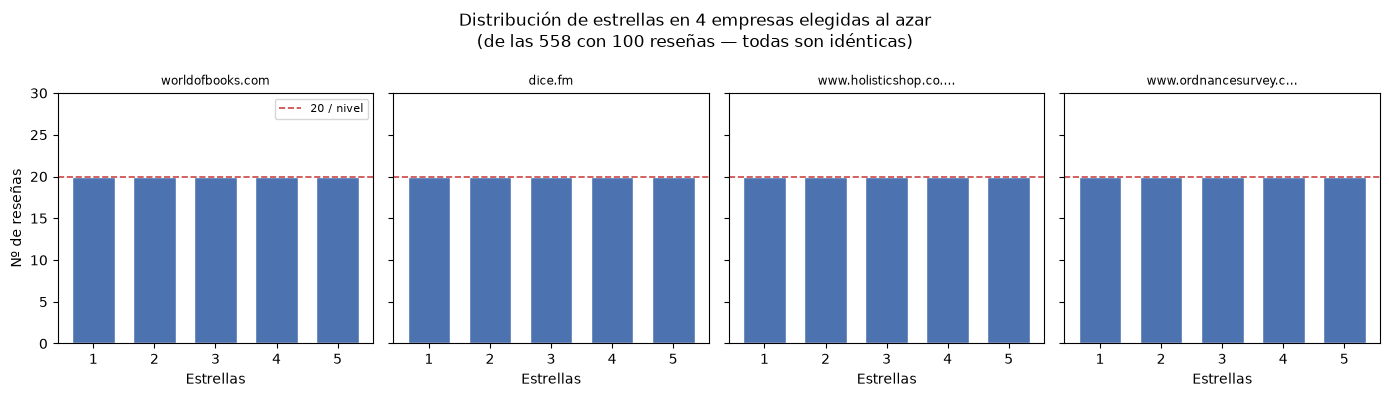

Guardado: outputs/figures/fase1_sesgo_estrellas.png


In [244]:
# Muestra visual: 4 empresas al azar del grupo estratificado
# Si fueran orgánicas, veríamos formas distintas; al ser forzadas, todas salen iguales.
rng = np.random.default_rng(SEED)
empresas_muestra = rng.choice(e100["company"].values, size=4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
fig.suptitle(
    "Distribución de estrellas en 4 empresas elegidas al azar\n"
    "(de las 558 con 100 reseñas — todas son idénticas)",
    fontsize=12,
)

for ax, empresa in zip(axes, empresas_muestra):
    conteo = (
        df_raw[df_raw["company"] == empresa]["stars"]
        .value_counts()
        .sort_index()
    )
    ax.bar(conteo.index, conteo.values, color="#4C72B0", edgecolor="white", width=0.7)
    # Línea de referencia: 20 reseñas es el valor forzado por nivel
    ax.axhline(20, color="#CC4444", linestyle="--", linewidth=1.2, label="20 / nivel")
    label = empresa[:20] + "…" if len(empresa) > 20 else empresa
    ax.set_title(label, fontsize=8.5)
    ax.set_xlabel("Estrellas")
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_ylim(0, 30)

axes[0].set_ylabel("Nº de reseñas")
axes[0].legend(fontsize=8)

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "eda_sesgo_estrellas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/eda_sesgo_estrellas.png")

**Justificación del sector — ¿por qué Money & Insurance?**

La tabla de la celda siguiente compara los 22 sectores en las dos dimensiones que el dato puede medir directamente: tamaño del pool disponible (empresas con 100 reseñas) y longitud media de las reseñas (riqueza de señal textual). Sobre esas dos métricas, Money & Insurance no es la opción más grande ni la de reseñas más largas — Vehicles & Transportation tiene 45 empresas y Travel & Vacation tiene las reseñas más largas (76 palabras).

La razón por la que se elige Money & Insurance está en lo que el dato no puede medir directamente: la **comparabilidad interna de topics**. Éste es un argumento de dominio, no un resultado del dato, y se declara explícitamente porque no puede verificarse sin correr el modelo de temas (sección 5).

**El razonamiento:** los nombres de los sectores candidatos con mayor pool son suficientes para inferir su heterogeneidad interna:

| Sector candidato | emp_100 | Por qué su pool interno es heterogéneo |
|---|---|---|
| Vehicles & Transportation | 45 | Agrupa talleres de reparación, alquiler de coches, parkings, concesionarios y taxis — negocios con topics distintos por definición |
| Travel & Vacation | 37 | Mezcla aerolíneas, casas rurales, agencias de viaje y operadores turísticos |
| Home & Garden | 37 | Mezcla muebles, herramientas, jardinería, reformas |
| **Money & Insurance** | **30** | El núcleo son bancos y neobancos: mismo producto (cuenta, tarjeta, app, atención, hipoteca) → topics comparables entre empresas |

Con 30 empresas el pool es suficiente para construir un grupo comparable, y la longitud de 64 palabras/reseña garantiza señal textual. La decisión combina un dato cuantificable (tamaño del pool) y un juicio de negocio declarado (homogeneidad sectorial).

Un argumento adicional, también de dominio: la formación económica permite interpretar los resultados con criterio financiero, y el proyecto se diferencia del trabajo de un compañero que analizó Travel & Vacation (TUI).

In [245]:
# Scoring de sectores: pool disponible y longitud de reseñas
df_raw["review_len"] = df_raw["review"].str.split().str.len()

stats_sector = df_raw.groupby("category").agg(
    empresas_total=("company", "nunique"),
    long_media=("review_len", "mean"),
).reset_index()

# Nº de empresas con exactamente 100 reseñas por sector → tamaño máximo del pool
e100_global = (
    df_raw.groupby("company")["review"]
    .count()
    .pipe(lambda s: s[s == 100])
    .reset_index(name="n")
)
e100_global["category"] = e100_global["company"].map(
    df_raw.drop_duplicates("company").set_index("company")["category"]
)
pool_por_sector = e100_global.groupby("category").size().rename("empresas_100").reset_index()

sector_scoring = (
    stats_sector
    .merge(pool_por_sector, on="category", how="left")
    .fillna({"empresas_100": 0})
    .assign(empresas_100=lambda d: d["empresas_100"].astype(int))
    .sort_values("empresas_100", ascending=False)
)

print("Sectores disponibles — ordenados por tamaño del pool (empresas con 100 reseñas):\n")
print(
    sector_scoring[["category", "empresas_total", "empresas_100", "long_media"]]
    .rename(columns={"empresas_total": "emp_total", "empresas_100": "emp_100", "long_media": "palabras/reseña"})
    .to_string(index=False, float_format="{:.0f}".format)
)
print()
# Resaltar el sector elegido
mi_sector = sector_scoring[sector_scoring["category"] == "Money & Insurance"].iloc[0]
print(
    f"Sector elegido: Money & Insurance  |  "
    f"pool_disponible={mi_sector['empresas_100']}  |  "
    f"palabras/reseña={mi_sector['long_media']:.0f}"
)

Sectores disponibles — ordenados por tamaño del pool (empresas con 100 reseñas):

                    category  emp_total  emp_100  palabras/reseña
   Vehicles & Transportation         60       45               64
               Home & Garden         76       37               67
           Travel & Vacation         57       37               76
          Shopping & Fashion         67       36               57
    Electronics & Technology         69       36               62
          Media & Publishing         59       33               61
                   Utilities         68       31               68
           Money & Insurance         70       30               64
            Health & Medical         76       28               70
      Events & Entertainment         76       25               64
Construction & Manufacturing         67       25               60
                      Sports         87       24               55
           Business Services         89       24            

**Conclusión:** El dataset tiene estratificación artificial de diseño: exactamente 20 reseñas por nivel de estrellas en cada empresa del grupo de 100. No es fraude de las empresas; es una decisión del creador del conjunto de datos. Las estrellas quedan fuera del análisis como variable de resultado. El sentimiento se mide desde el texto (sección 3). Las comparaciones reportan diferencias empresa vs. pool — con el mismo sesgo en ambos lados, la diferencia es limpia.

---
## 2. Empresa objetivo y pool de competencia

**Qué hacemos:** elegir el target entre 3 finalistas con 6 criterios basados en datos, y construir el pool de competidores por similitud semántica entre las descripciones de empresa.

**Orden obligatorio de los filtros:**
1. Reducir a empresas con exactamente 100 reseñas (mismo diseño muestral → comparación justa).
2. *Dentro de ese subconjunto*, medir similitud coseno sobre `description`. Invertir el orden reintroduciría el sesgo del EDA anterior.

**Los 6 criterios para el target:**

| # | Criterio | Qué mide |
|---|---|---|
| 1 | Pool denso | ¿cuántos competidores genuinos hay disponibles? |
| 2 | Topics variados | ¿la empresa toca líneas distintas (cuenta, tarjeta, app, hipoteca…)? |
| 3 | Historia clara | ¿hay un contraste que contar a dirección? |
| 4 | Reseñas con cuerpo | ¿son informativas o de una línea? |
| 5 | Topics compartidos con el pool | ¿los mismos temas aparecen en los rivales? |
| 6 | Dominio conocido | ¿puedo interpretar los resultados con criterio económico? |

**¿Qué mide la similitud coseno aquí y cómo se calcula?**

Antes de leer el gráfico hay una distinción importante: **la similitud coseno se calculó sobre las `description`** — el texto corto que cada empresa usa para describir a qué se dedica —, no sobre las reseñas de los clientes. Usamos las descripciones porque capturan lo que la empresa *hace*, que es exactamente lo que determina si es un competidor comparable.

**La matemática paso a paso:**

1. `all-MiniLM-L6-v2` toma el texto de cada description y lo convierte en un vector de **384 números**. Esos números no corresponden a palabras concretas — capturan el *significado* del texto en un espacio de 384 dimensiones. Una frase como "retail banking for individuals" y otra como "banco minorista para clientes particulares" producirían vectores muy similares aunque no compartan ni una palabra.

2. Para comparar la description de HSBC (vector **A**) con la de cualquier otra empresa (vector **B**):

   **cos(θ) = (A · B) / (|A| × |B|)**

   donde θ es el ángulo entre los dos vectores. La operación mide la **dirección** en que apuntan, no la magnitud. Dos vectores apuntando hacia el mismo rincón del espacio semántico —aunque de distinto tamaño— tendrán cos(θ) = 1. Si son perpendiculares (sin relación semántica), cos(θ) = 0.

3. **Diferencia clave con TF-IDF:** TF-IDF cuenta cuántas palabras exactas coinciden (solapamiento léxico). Los embeddings capturan si los textos hablan *de lo mismo* —un sinónimo, una paráfrasis o una traducción pueden dar similitud alta sin compartir ninguna palabra.

**Cómo leer el coeficiente:** Virgin Money = 0.478 significa que su descripción apunta hacia la misma dirección semántica que la de HSBC en un ~48%. El umbral de 0.28 coincide con la media de similitud del conjunto (~0.27) y, no por casualidad, marca el punto donde la lista pasa de bancos genuinos a servicios de cashback, cripto e inmobiliarias — el modelo los separa solo, sin que nosotros fijemos una regla.

In [246]:
import warnings
warnings.filterwarnings("ignore")

# ── Paso 1: subconjunto banca con 100 reseñas ────────────────────────────────
banca = df_raw[df_raw["category"] == "Money & Insurance"].copy()
banca["review_len"] = banca["review"].str.split().str.len()

banca_100_names = (
    banca.groupby("company")["stars"]
    .count()
    .pipe(lambda s: s[s == 100])
    .index.tolist()
)
df_banca = banca[banca["company"].isin(banca_100_names)].copy()
print(f"Subconjunto banca: {len(banca_100_names)} empresas · {len(df_banca)} reseñas")

# ── Paso 2: primer filtro — ¿la descripción habla de banca? ─────────────────
# Palabras que aparecen en descriptions de entidades bancarias reales
bank_kw = ["bank", "banking", "savings", "lending",
           "mortgage", "current account", "financial services"]

descs_lower = df_banca.drop_duplicates("company").set_index("company")["description"].str.lower()
tipo_banco = descs_lower.apply(lambda d: any(k in d for k in bank_kw))

# Segundo filtro manual: falsos positivos del primer filtro
# wirexapp y blockchain.com usan "banking" pero son plataformas cripto/Web3
# saladmoney.co.uk: préstamos alternativos nicho (47 palabras/reseña, señal débil)
# www.unbiased.co.uk: plataforma de asesores financieros, no un banco
NO_BANCO = {"wirexapp.com", "blockchain.com", "saladmoney.co.uk", "www.unbiased.co.uk"}

bancos_reales = [e for e in tipo_banco[tipo_banco].index if e not in NO_BANCO]
print(f"\nCandidatos banco genuino: {len(bancos_reales)}")

# ── Paso 3: scoring de topics para TODOS los candidatos ─────────────────────
# Esto es lo que debería guiar la elección de finalistas, no el conocimiento previo
keywords = {
    "cuenta":      ["account", "current account", "savings"],
    "app":         ["app", "mobile", "online banking"],
    "atención":    ["customer service", "support", "staff", "helpline"],
    "tarjeta":     ["card", "credit card", "debit card"],
    "transfer":    ["transfer", "payment", "send money"],
    "fraude":      ["fraud", "scam", "stolen", "dispute"],
    "hipoteca":    ["mortgage", "loan"],
}

rows = []
for emp in bancos_reales:
    r = df_banca[df_banca["company"] == emp]["review"].str.lower()
    lm = df_banca[df_banca["company"] == emp]["review_len"].mean()
    pcts = {t: r.str.contains("|".join(kws)).mean() * 100 for t, kws in keywords.items()}
    n_top = sum(1 for p in pcts.values() if p >= 20)
    rows.append({"empresa": emp, "long_media": lm, "n_topics_20": n_top, **pcts})

scoring = pd.DataFrame(rows).sort_values("long_media", ascending=False).reset_index(drop=True)

print("\nScoring completo — todos los candidatos banco (ordenados por riqueza de reseñas):")
cols_show = ["empresa", "long_media", "n_topics_20"] + list(keywords.keys())
print(scoring[cols_show].to_string(index=False, float_format="{:.0f}".format))

# ── Paso 4: elección del target ──────────────────────────────────────────────
# De los datos: HSBC lidera en longitud (89w) y comparte liderazgo en topics (5).
# Santander es el segundo más cercano (86w, 4 topics).
# Zopa tiene el mayor nº de topics (6) pero sus reseñas son más cortas (72w) y
# sus topics están concentrados en préstamos/hipotecas (transfer 39%, hipoteca 34%),
# lo que lo hace menos representativo de banca retail generalista.
# HSBC cubre 5 topics de forma equilibrada → mayor riqueza analítica.
FINALISTAS = ["www.hsbc.co.uk", "www.santander.co.uk", "zopa.com"]
TARGET = "www.hsbc.co.uk"
print(f"\nFinalistas evaluados: {FINALISTAS}")
print(f"Target seleccionado:  {TARGET}")

Subconjunto banca: 30 empresas · 3000 reseñas

Candidatos banco genuino: 11

Scoring completo — todos los candidatos banco (ordenados por riqueza de reseñas):
            empresa  long_media  n_topics_20  cuenta  app  atención  tarjeta  transfer  fraude  hipoteca
     www.hsbc.co.uk          89            5      52   50        40       21        20       8         8
www.santander.co.uk          86            4      40   45        29       16        20      18         3
www.firstdirect.com          78            4      40   67        28       16        22       4         5
          tsb.co.uk          72            3      39   56        34       13        11      11        12
           zopa.com          72            6      33   43        24       31        39       3        34
      www.monzo.com          68            5      44   43        29       22        21      16         6
        chase.co.uk          68            5      67   53        20       20        21      14         2
w

Ranking de similitud coseno con el target (sobre descripciones de empresa):
                      company  similitud_coseno
           uk.virginmoney.com            0.4779
                    tsb.co.uk            0.4427
                  chase.co.uk            0.4143
                      tide.co            0.3856
          www.firstdirect.com            0.3763
www.startlinemotorfinance.com            0.3575
           www.unbiased.co.uk            0.3171
                     zopa.com            0.3125
          www.santander.co.uk            0.3093
            www.tescobank.com            0.3046
                 wirexapp.com            0.3028
          www.aldermore.co.uk            0.2879
               blockchain.com            0.2879
             saladmoney.co.uk            0.2860
                www.monzo.com            0.2839
             smallworldfs.com            0.2734
           www.cashback.co.uk            0.2732
               transfergo.com            0.2711
            

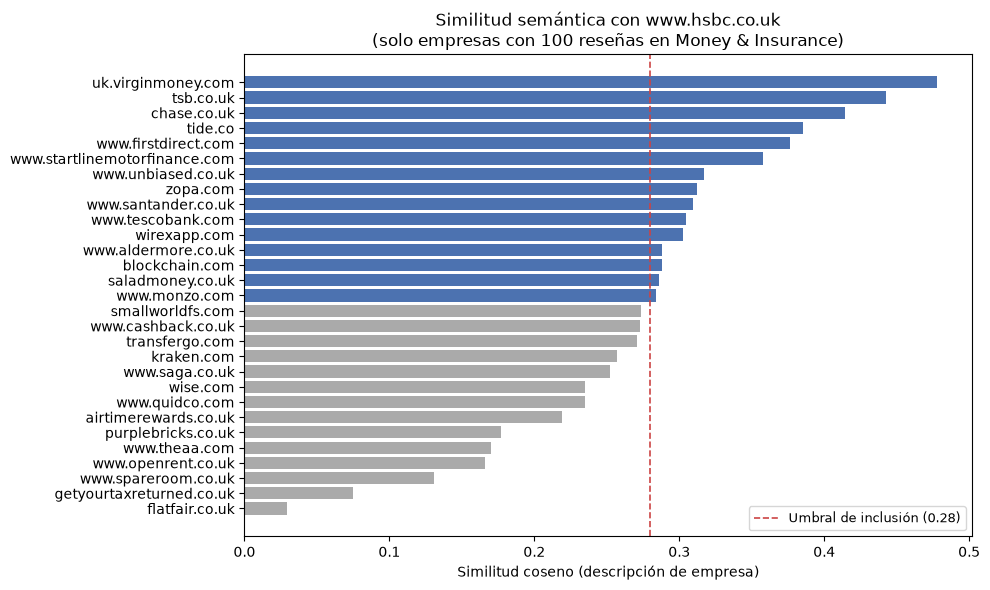

Guardado: outputs/figures/fase2_similitud_pool.png


In [247]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# ── Embeddings de descriptions ───────────────────────────────────────────────
# all-MiniLM-L6-v2: 384 dimensiones, rápido en CPU, bueno para frases cortas.
# Alternativa más potente (all-mpnet-base-v2) no compensa el coste extra
# en un corpus de 30 descriptions muy cortas.
descs = df_banca.drop_duplicates("company")[["company", "description"]].reset_index(drop=True)

model_emb = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model_emb.encode(descs["description"].tolist(), show_progress_bar=False)

# ── Similitud coseno: TARGET vs. todos ──────────────────────────────────────
target_idx = descs[descs["company"] == TARGET].index[0]
sims = cosine_similarity(embeddings[target_idx : target_idx + 1], embeddings)[0]

descs["similitud_coseno"] = sims.round(4)
pool_ranked = (
    descs[descs["company"] != TARGET]
    .sort_values("similitud_coseno", ascending=False)
    .reset_index(drop=True)
)

print("Ranking de similitud coseno con el target (sobre descripciones de empresa):")
print(pool_ranked[["company", "similitud_coseno"]].to_string(index=False))

# ── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
colores = [
    "#4C72B0" if sim >= 0.28 else "#AAAAAA"
    for sim in pool_ranked["similitud_coseno"]
]
ax.barh(pool_ranked["company"][::-1], pool_ranked["similitud_coseno"][::-1], color=colores[::-1])
ax.axvline(0.28, color="#CC4444", linestyle="--", linewidth=1.2, label="Umbral de inclusión (0.28)")
ax.set_xlabel("Similitud coseno (descripción de empresa)")
ax.set_title(f"Similitud semántica con {TARGET}\n(solo empresas con 100 reseñas en Money & Insurance)")
ax.legend(fontsize=9)
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "pool_similitud_coseno.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/pool_similitud_coseno.png")

In [248]:
# ── Revisión manual del pool ─────────────────────────────────────────────────
# El coseno ordena por similitud semántica, pero no distingue entre un banco
# retail y una plataforma de cashback. El criterio de negocio tiene la última palabra.
#
# ELIMINADOS del pool final (razón documentada):
#
#   www.startlinemotorfinance.com (sim 0.358) — financiación de vehículos, no banca retail
#   www.unbiased.co.uk (sim 0.317)            — plataforma de asesores, no banco
#
#   www.firstdirect.com (sim 0.376) — subsidiaria de HSBC con marca propia.
#     Excluida por razón metodológica: es la referencia de atención al cliente en UK y
#     el hallazgo central del proyecto es precisamente la brecha de HSBC en atención
#     (40% de sus reseñas lo mencionan). Incluirla en el pool inflaría el baseline del
#     sector y suavizaría artificialmente la diferencia más importante del análisis.
#     Conceptualmente: HSBC no compite contra sí mismo.

POOL = [
    "uk.virginmoney.com",      # 0.478 — banco retail UK, 6º más grande
    "tsb.co.uk",               # 0.443 — banco retail tradicional
    "chase.co.uk",             # 0.414 — banco digital (JPMorgan Chase UK)
    "tide.co",                 # 0.386 — banca de negocio para autónomos/pymes
    "zopa.com",                # 0.312 — banco digital (préstamos y ahorro)
    "www.santander.co.uk",     # 0.309 — banco retail multinacional
    "www.tescobank.com",       # 0.305 — banco retail (tarjetas, ahorro, préstamos)
    "www.aldermore.co.uk",     # 0.288 — banco especialista en pymes y ahorro
    "www.monzo.com",           # 0.284 — banco digital challenger
]

# ── Dataset de trabajo: target + pool ────────────────────────────────────────
TARGET_POOL = [TARGET] + POOL
df_sub = df_banca[df_banca["company"].isin(TARGET_POOL)].copy().reset_index(drop=True)

print(f"TARGET : {TARGET} ({len(df_sub[df_sub['company'] == TARGET])} reseñas)")
print(f"POOL   : {len(POOL)} empresas")
print(f"TOTAL  : {len(df_sub)} reseñas\n")
print("Composición del pool:")
for emp in POOL:
    n = len(df_sub[df_sub["company"] == emp])
    sim = pool_ranked[pool_ranked["company"] == emp]["similitud_coseno"].values[0]
    print(f"  {emp:35s}  sim={sim:.3f}  ({n} reseñas)")

# ── Guardar a disco ───────────────────────────────────────────────────────────
# CSV en data/processed/ — accesible sin dependencias adicionales,
# igual de rápido para 1.000 filas, legible con cualquier herramienta.
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df_sub.to_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv", index=False)
print(f"\nGuardado: data/processed/df_sub.csv  ({len(df_sub)} filas × {len(df_sub.columns)} columnas)")

TARGET : www.hsbc.co.uk (100 reseñas)
POOL   : 9 empresas
TOTAL  : 1000 reseñas

Composición del pool:
  uk.virginmoney.com                   sim=0.478  (100 reseñas)
  tsb.co.uk                            sim=0.443  (100 reseñas)
  chase.co.uk                          sim=0.414  (100 reseñas)
  tide.co                              sim=0.386  (100 reseñas)
  zopa.com                             sim=0.312  (100 reseñas)
  www.santander.co.uk                  sim=0.309  (100 reseñas)
  www.tescobank.com                    sim=0.305  (100 reseñas)
  www.aldermore.co.uk                  sim=0.288  (100 reseñas)
  www.monzo.com                        sim=0.284  (100 reseñas)

Guardado: data/processed/df_sub.csv  (1000 filas × 7 columnas)


**Conclusión:** Target = `www.hsbc.co.uk` (elegido por mayor riqueza de reseñas —89 palabras/media— y cobertura equilibrada de 5 topics ≥20%). Pool = 9 bancos independientes seleccionados por similitud coseno sobre `description`, con revisión manual que excluyó 3 empresas: `startlinemotorfinance` (financiación de vehículos), `unbiased` (plataforma de asesores) y `firstdirect` (subsidiaria de HSBC — excluida para preservar la validez del hallazgo central en atención al cliente).

A partir de aquí trabajamos únicamente con `df_sub`: **1.000 reseñas** (100 HSBC + 9×100 competidores). Las 123k reseñas restantes no vuelven a tocarse.

---
## 3. Exploración y limpieza del texto

**Qué hacemos:** preparar el texto para los dos modelos que vienen. Cada modelo necesita una versión distinta porque sus requisitos son opuestos.

**Decisión de diseño — texto base:** se concatena `title + " " + review` antes de limpiar. El título captura la esencia de la reseña en pocas palabras; añadirlo al cuerpo enriquece la señal para el topic modeling sin distorsionar el sentimiento (el nlptown toma los primeros 512 tokens, que siempre incluirán el título).

**Las dos limpiezas:**

| | Ligera (sentimiento) | Pesada (temas) |
|---|---|---|
| Base de texto | `title + " " + review` | `title + " " + review` |
| Mayúsculas, signos, emojis | se conservan | se quitan |
| Negaciones ("no", "never") | **se conservan** | se quitan |
| Stop words ("the", "a") | se conservan | **se quitan** |
| HTML y URLs | se quitan | se quitan |

**Por qué dos versiones:**
- El sentimiento depende del tono completo: "NOT a good experience" es negativo solo si conservas "NOT". Si lo quitas, el modelo puede leerlo como positivo.
- Los topics necesitan las palabras con contenido semántico, sin el ruido de preposiciones y artículos que enturbian el TF-IDF.

In [249]:
import re

def limpiar_ligero(texto: str) -> str:
    """
    Limpieza mínima para el modelo de sentimiento.

    Quita solo HTML y URLs; conserva mayúsculas, signos, emojis y negaciones
    porque el tono depende de ellos.

    Parameters
    ----------
    texto : str

    Returns
    -------
    str
    """
    texto = re.sub(r"<[^>]+>", " ", texto)          # HTML
    texto = re.sub(r"http\S+|www\.\S+", " ", texto) # URLs
    return texto.strip()


def limpiar_pesado(texto: str, stop_words: set) -> str:
    """
    Limpieza agresiva para topic modeling.

    Quita HTML, URLs, signos, números, mayúsculas y stop words.
    Lo que queda son las palabras con contenido semántico.

    Parameters
    ----------
    texto : str
    stop_words : set

    Returns
    -------
    str
    """
    texto = re.sub(r"<[^>]+>", " ", texto)
    texto = re.sub(r"http\S+|www\.\S+", " ", texto)
    texto = texto.lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)
    tokens = [t for t in texto.split() if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df_sub cargado: 1000 filas · 10 empresas

Distribución de longitud (title + review, palabras):
count    1000.0
mean       75.3
std        54.5
min         7.0
25%        41.0
50%        62.5
75%        95.0
max       778.0
Name: n_palabras, dtype: float64

Percentil 95: 173 palabras | Percentil 99: 269 palabras
Reseñas con > 380 palabras (posible truncamiento en nlptown): 2

Duplicados exactos: 0
Reseñas posiblemente no inglés (>10% chars no-ASCII): 0


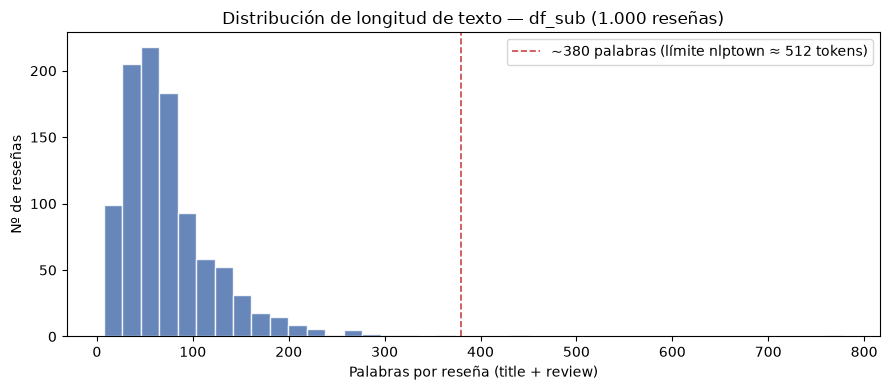

Guardado: outputs/figures/fase3_longitud_texto.png

Stop words: 338 total (318 sklearn + 33 dominio)


In [250]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# ── Carga desde disco ─────────────────────────────────────────────────────────
# Phase 3 es ejecutable sin reejecutar : carga directamente el CSV de trabajo.
PROCESSED_DIR = ROOT / "data" / "processed"
df_sub = pd.read_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv")
print(f"df_sub cargado: {len(df_sub)} filas · {df_sub['company'].nunique()} empresas\n")

# ── Texto base: title + review ────────────────────────────────────────────────
# El título resume la experiencia en pocas palabras y enriquece la señal de topics.
# Para el sentimiento no cambia nada: nlptown toma los primeros 512 tokens,
# que siempre incluyen el título.
df_sub["texto"] = df_sub["title"].fillna("") + " " + df_sub["review"].fillna("")
df_sub["n_palabras"] = df_sub["texto"].str.split().str.len()

# ── Exploración de longitudes ─────────────────────────────────────────────────
print("Distribución de longitud (title + review, palabras):")
print(df_sub["n_palabras"].describe().round(1))
p95, p99 = df_sub["n_palabras"].quantile([0.95, 0.99])
print(f"\nPercentil 95: {p95:.0f} palabras | Percentil 99: {p99:.0f} palabras")
# nlptown trunca a 512 tokens ≈ ~380 palabras inglés estándar.
# p99 = 269 → el truncamiento afecta a < 1% de las reseñas. No es un problema.
print(f"Reseñas con > 380 palabras (posible truncamiento en nlptown): "
      f"{(df_sub['n_palabras'] > 380).sum()}")

# ── Duplicados ────────────────────────────────────────────────────────────────
n_dup = df_sub.duplicated(subset="texto").sum()
print(f"\nDuplicados exactos: {n_dup}")
# Si hubiera duplicados, los quitaríamos antes de TF-IDF en la Fase 5.
# No hay duplicados: el dataset está limpio en este sentido.

# ── Detección de idioma (proxy: proporción de caracteres no-ASCII) ────────────
# Una reseña con > 10% de caracteres no-ASCII probablemente no es inglés.
df_sub["pct_no_ascii"] = df_sub["texto"].apply(
    lambda t: sum(1 for c in t if ord(c) > 127) / max(len(t), 1)
)
n_no_ingles = (df_sub["pct_no_ascii"] > 0.1).sum()
print(f"Reseñas posiblemente no inglés (>10% chars no-ASCII): {n_no_ingles}")
# 0 → el corpus es íntegramente inglés. Plataforma UK, esperado.

# ── Visualización: distribución de longitudes ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_sub["n_palabras"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(380, color="#CC4444", linestyle="--", linewidth=1.2,
           label="~380 palabras (límite nlptown ≈ 512 tokens)")
ax.set_xlabel("Palabras por reseña (title + review)")
ax.set_ylabel("Nº de reseñas")
ax.set_title("Distribución de longitud de texto — df_sub (1.000 reseñas)")
ax.legend()
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "eda_longitud_texto.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/eda_longitud_texto.png")

# ── Stop words ────────────────────────────────────────────────────────────────
# Base: sklearn ENGLISH_STOP_WORDS (318 términos).
# Adiciones: verbos de opinión genéricos que enturbian el TF-IDF sin aportar topic.
# "bank"/"banking" no se añaden: TF-IDF ya los penaliza vía IDF bajo (aparecen en todo).
EXTRA_SW = {
    "would", "could", "also", "even", "really", "just", "actually", "always",
    "still", "never", "ever", "use", "used", "get", "got", "make", "made",
    "year", "years", "month", "months", "week", "day", "time", "ago",
    "one", "two", "three", "said", "told", "asked", "called", "tried",
}
STOP_WORDS = set(ENGLISH_STOP_WORDS) | EXTRA_SW
print(f"\nStop words: {len(STOP_WORDS)} total "
      f"({len(ENGLISH_STOP_WORDS)} sklearn + {len(EXTRA_SW)} dominio)")

In [251]:
# ── Aplicar las dos limpiezas al texto base ───────────────────────────────────
df_sub["texto_ligero"] = df_sub["texto"].apply(limpiar_ligero)
df_sub["texto_pesado"] = df_sub["texto"].apply(
    lambda x: limpiar_pesado(x, STOP_WORDS)
)

# ── Validación: comparación antes/después en una reseña real ─────────────────
# Muestra una reseña de HSBC para verificar que la limpieza funciona como espera.
idx = df_sub[df_sub["company"] == "www.hsbc.co.uk"].index[0]

print("═" * 70)
print("ORIGINAL (title + review):")
print(df_sub.loc[idx, "texto"][:400])
print()
print("LIGERO (para sentimiento — conserva tono y negaciones):")
print(df_sub.loc[idx, "texto_ligero"][:400])
print()
print("PESADO (para topics — queda el contenido semántico puro):")
print(df_sub.loc[idx, "texto_pesado"][:400])
print("═" * 70)

# ── Estadísticos de la limpieza ───────────────────────────────────────────────
df_sub["n_palabras_pesado"] = df_sub["texto_pesado"].str.split().str.len()
print(f"\nPalabras promedio tras limpieza pesada: {df_sub['n_palabras_pesado'].mean():.0f}")
print(f"Palabras promedio texto original:        {df_sub['n_palabras'].mean():.0f}")
print(f"Reducción media por stop words:          "
      f"{(1 - df_sub['n_palabras_pesado'] / df_sub['n_palabras']).mean() * 100:.0f}%")
n_cortas = (df_sub["n_palabras_pesado"] < 5).sum()
print(f"Reseñas con < 5 palabras tras limpieza: {n_cortas} "
      f"(marcar como 'sin señal' en F5 si persisten)")

# ── Guardar df_sub actualizado con las columnas de texto ─────────────────────
# El CSV pasa de 6 columnas (carga) a 10 (+ texto, n_palabras, texto_ligero, texto_pesado).
# n_palabras_pesado y pct_no_ascii se excluyen; son métricas auxiliares de exploración.
columnas_guardar = [
    "category", "company", "description", "title", "review", "stars",
    "texto", "texto_ligero", "texto_pesado",
]
df_sub[columnas_guardar].to_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv", index=False)
print(f"\nGuardado: data/processed/df_sub.csv  "
      f"({len(df_sub)} filas × {len(columnas_guardar)} columnas)")

══════════════════════════════════════════════════════════════════════
ORIGINAL (title + review):
Visited Leicester clock tower branch… Visited Leicester clock tower branch for updating my details where Deepali helped us. She also helped in balance transfer too. She was amazing and excellent customer service from her. Thank you. 

LIGERO (para sentimiento — conserva tono y negaciones):
Visited Leicester clock tower branch… Visited Leicester clock tower branch for updating my details where Deepali helped us. She also helped in balance transfer too. She was amazing and excellent customer service from her. Thank you.

PESADO (para topics — queda el contenido semántico puro):
visited leicester clock tower branch visited leicester clock tower branch updating details deepali helped helped balance transfer amazing excellent customer service thank
══════════════════════════════════════════════════════════════════════

Palabras promedio tras limpieza pesada: 32
Palabras promedio texto original:

**Conclusión:**

**Texto base:** `title + " " + review` — el título en Trustpilot suele ser la primera frase de la reseña, por lo que la concatenación produce un leve eco al inicio del texto. No es un problema: TF-IDF pondera por frecuencia relativa dentro del documento y las palabras repetidas al principio no sesgan el resultado del topic modeling.

**Hallazgos de la exploración:**
- Sin duplicados exactos (0 de 1.000) — el corpus no necesita limpieza adicional antes de TF-IDF.
- Sin reseñas en otros idiomas (0% caracteres no-ASCII) — corpus íntegramente inglés, esperado para plataforma UK.
- Media 75 palabras; p99=269 palabras. Solo 2 reseñas superan el umbral de truncamiento de nlptown (~380 palabras) — marginal, no afecta al análisis.

**Resultado de la limpieza:**
- `texto_ligero`: HTML y URLs eliminados; tono intacto (mayúsculas, signos, negaciones). Listo para F4.
- `texto_pesado`: minúsculas, sin signos, sin stop words (sklearn + dominio). Reducción media del 55%: de 75 palabras a 32 palabras semánticas. Listo para F5.

Las 2 reseñas con menos de 5 palabras tras la limpieza pesada serán marcadas como "sin señal suficiente" en el topic modeling si distorsionan algún topic.

---
## 4. Sentimiento (¿hablan bien o mal?)

**Qué hacemos:** asignar nota 1-5 a cada reseña con `nlptown/bert-base-multilingual-uncased-sentiment`, un transformer ya entrenado en reseñas de múltiples idiomas. No entrenamos nada: tomamos prestado un modelo que ya aprendió el vínculo entre texto y tono. Es transfer learning aplicado al caso más práctico posible.

**Decisiones de diseño:**
- Entrada: `texto_ligero` — con negaciones y mayúsculas intactas, tal como el humano lo escribió.
- Solo sobre target + pool (~1.000 reseñas) — nunca sobre las 123k.
- **Negativa = nota 1 o 2. Nota 3 = ambigua, se aparta del análisis de F6.**
- Cacheado en `df_sub.csv`: si la columna `nlptown_stars` ya existe, el modelo no se vuelve a ejecutar.

**Por qué nota 3 = ambigua:** el 3 es el centro exacto de la escala y captura reseñas mixtas ("buen producto, mal servicio") y neutras indistinguibles. Mezclarlas con negativas o positivas introduce ruido sistemático en el cruce tema × sentimiento — como lo haría mezclar electorado indeciso en una encuesta de intención de voto.

Cargando modelo nlptown/bert-base-multilingual-uncased-sentiment...
Modelo listo.

Procesando 1000 reseñas en lotes de 16 (≈5 min en Mac Intel)...
  976/1000
Guardado: data/processed/df_sub.csv  (+2 columnas)

Distribución de nota nlptown (1-5) — 1.000 reseñas:
  1★  398 reseñas  ███████████████████████████████████████████████████████████████████████████████
  2★  159 reseñas  ███████████████████████████████
  3★   89 reseñas  █████████████████
  4★  123 reseñas  ████████████████████████
  5★  231 reseñas  ██████████████████████████████████████████████


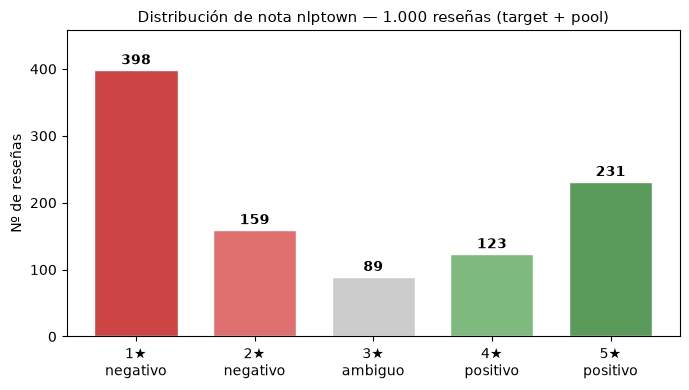

Guardado: outputs/figures/fase4_distribucion_estrellas.png

Confianza media del modelo:     0.636
Confianza mediana:              0.608
Reseñas con score < 0.50:       29.7%  (fronterizas)
Reseñas con score > 0.80:       25.8%  (decisivas)


In [252]:
import warnings
import torch
warnings.filterwarnings("ignore")

# ── Carga desde disco ─────────────────────────────────────────────────────────
PROCESSED_DIR = ROOT / "data" / "processed"
df_sub = pd.read_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv")

if "nlptown_stars" in df_sub.columns:
    print(f"Sentimiento ya calculado — cargando desde df_sub.csv ({len(df_sub)} reseñas).")
else:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    # ── Por qué no usamos pipeline() ──────────────────────────────────────────
    # pipeline() abstrae tokenizador + modelo + DataLoader. En Jupyter, el ciclo
    # interno del DataLoader (y los callbacks Rust→Python del tokenizador rápido)
    # desbordan el límite de recursión de Python (1.000 por defecto).
    # Bajando al nivel AutoTokenizer + AutoModel eliminamos esa capa problemática:
    # tokenizamos en Python, pasamos los tensores al modelo, leemos el argmax.
    # Es exactamente lo que pipeline() hace, pero sin los intermediarios.
    MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
    print(f"Cargando modelo {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
    model.eval()
    print("Modelo listo.\n")

    textos    = df_sub["texto_ligero"].tolist()
    n         = len(textos)
    orden     = sorted(range(n), key=lambda i: len(textos[i]))
    textos_ord = [textos[i] for i in orden]

    BATCH         = 16
    estrellas_ord = []
    scores_ord    = []

    print(f"Procesando {n} reseñas en lotes de {BATCH} (≈5 min en Mac Intel)...")
    for i in range(0, n, BATCH):
        lote   = textos_ord[i : i + BATCH]
        inputs = tokenizer(lote, truncation=True, max_length=512,
                           padding=True, return_tensors="pt")
        with torch.no_grad():
            logits = model(**inputs).logits
        probs  = torch.softmax(logits, dim=1)
        clases = probs.argmax(dim=1).tolist()
        confs  = probs.max(dim=1).values.tolist()
        estrellas_ord.extend(c + 1 for c in clases)
        scores_ord.extend(round(s, 4) for s in confs)
        if i % 160 == 0:
            print(f"  {min(i + BATCH, n)}/{n}", end="\r")

    estrellas = [None] * n
    scores    = [None] * n
    for pos, orig_i in enumerate(orden):
        estrellas[orig_i] = estrellas_ord[pos]
        scores[orig_i]    = scores_ord[pos]

    df_sub["nlptown_stars"] = estrellas
    df_sub["nlptown_score"] = scores
    df_sub.to_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv", index=False)
    print(f"\nGuardado: data/processed/df_sub.csv  (+2 columnas)")

# ── Distribución de notas (texto) ────────────────────────────────────────────
print("\nDistribución de nota nlptown (1-5) — 1.000 reseñas:")
dist = df_sub["nlptown_stars"].value_counts().sort_index()
for s, n_r in dist.items():
    print(f"  {s}★  {n_r:>3} reseñas  {'█'*(n_r//5)}")

# ── Gráfico: distribución de estrellas coloreada por categoría de sentimiento ─
# El color transmite directamente qué notas forman cada categoría.
COLORES_STAR = {1: "#CC4444", 2: "#E07070", 3: "#CCCCCC", 4: "#7EBA7E", 5: "#5A9A5A"}
fig, ax = plt.subplots(figsize=(7, 4))
for star, count in dist.items():
    ax.bar(star, count, color=COLORES_STAR[star], edgecolor="white", width=0.7)
    ax.text(star, count + 4, str(count), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(["1★\nnegativo", "2★\nnegativo", "3★\nambiguo",
                     "4★\npositivo", "5★\npositivo"])
ax.set_ylabel("Nº de reseñas")
ax.set_title("Distribución de nota nlptown — 1.000 reseñas (target + pool)", fontsize=11)
ax.set_ylim(0, max(dist.values) * 1.15)
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "sentimiento_distribucion_nlptown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/sentimiento_distribucion_nlptown.png")

# ── Confianza del modelo ──────────────────────────────────────────────────────
# nlptown_score es la probabilidad softmax asignada a la clase ganadora.
# Un score de 0.90 significa que el modelo distribuyó el 90% de la probabilidad
# en esa nota: alta seguridad. Un score de 0.35 refleja una reseña genuinamente
# fronteriza — y con frecuencia esas reseñas caen en nota 3 (ambiguo), que de
# todos modos queda fuera del análisis de .
print(f"\nConfianza media del modelo:     {df_sub['nlptown_score'].mean():.3f}")
print(f"Confianza mediana:              {df_sub['nlptown_score'].median():.3f}")
print(f"Reseñas con score < 0.50:       {(df_sub['nlptown_score'] < 0.50).mean()*100:.1f}%  (fronterizas)")
print(f"Reseñas con score > 0.80:       {(df_sub['nlptown_score'] > 0.80).mean()*100:.1f}%  (decisivas)")

Sentimiento por empresa (% sobre 100 reseñas cada una):

      empresa  neg%  amb%  pos%
        Monzo  47.0  12.0  41.0
    Aldermore  50.0  14.0  36.0
   Tesco Bank  53.0  10.0  37.0
 Virgin Money  54.0   9.0  37.0
     Chase UK  56.0  13.0  31.0
HSBC (TARGET)  57.0   4.0  39.0
         Tide  57.0   7.0  36.0
         Zopa  58.0   6.0  36.0
    Santander  61.0   7.0  32.0
          TSB  64.0   7.0  29.0


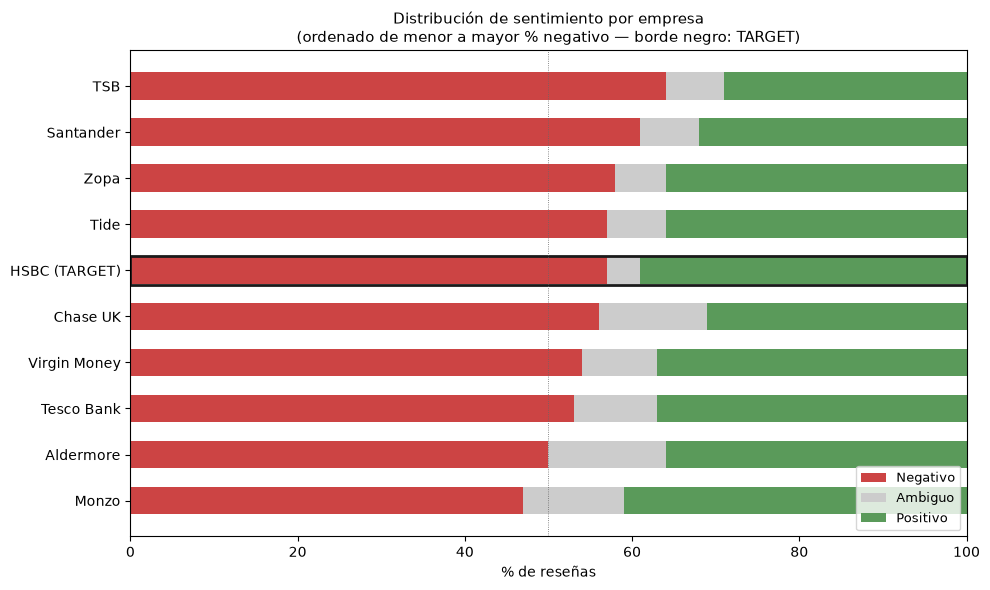

Guardado: outputs/figures/fase4_sentimiento_empresas.png

HSBC (TARGET)   — negativo: 57.0%   positivo: 39.0%
Pool (9 bancos) — negativo: 55.6%   positivo: 35.0%
Diferencia negatividad HSBC − pool: +1.4 pp

Esta diferencia es la señal de primer orden (nivel global).
El cruce con temas en F6 la descompone por área de servicio.


In [253]:
# ── Categorizar sentimiento ───────────────────────────────────────────────────
# 1-2 = negativo, 3 = ambiguo (fuera del análisis ), 4-5 = positivo
df_sub["sentimiento"] = df_sub["nlptown_stars"].map(
    {1: "negativo", 2: "negativo", 3: "ambiguo", 4: "positivo", 5: "positivo"}
)

# ── Tabla de resumen por empresa ──────────────────────────────────────────────
resumen = (
    df_sub.groupby("company")["sentimiento"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack(fill_value=0.0)
)
for col in ["negativo", "ambiguo", "positivo"]:
    if col not in resumen.columns:
        resumen[col] = 0.0

NOMBRE_CORTO = {
    "www.hsbc.co.uk":       "HSBC (TARGET)",
    "uk.virginmoney.com":   "Virgin Money",
    "tsb.co.uk":            "TSB",
    "chase.co.uk":          "Chase UK",
    "tide.co":              "Tide",
    "zopa.com":             "Zopa",
    "www.santander.co.uk":  "Santander",
    "www.tescobank.com":    "Tesco Bank",
    "www.aldermore.co.uk":  "Aldermore",
    "www.monzo.com":        "Monzo",
}
resumen["nombre"] = resumen.index.map(NOMBRE_CORTO)
resumen = resumen.sort_values("negativo", ascending=True)  # ordenar para el gráfico

print("Sentimiento por empresa (% sobre 100 reseñas cada una):\n")
tabla_print = (
    resumen[["nombre", "negativo", "ambiguo", "positivo"]]
    .rename(columns={"nombre": "empresa", "negativo": "neg%", "ambiguo": "amb%", "positivo": "pos%"})
)
print(tabla_print.to_string(index=False))

# ── Gráfico: barras horizontales apiladas ─────────────────────────────────────
# La ordenación de menor a mayor negatividad pone inmediatamente visible
# qué empresas tienen peor experiencia — y dónde cae HSBC.
fig, ax = plt.subplots(figsize=(10, 6))

COLORES = {"negativo": "#CC4444", "ambiguo": "#CCCCCC", "positivo": "#5A9A5A"}
labels = resumen["nombre"].tolist()
y_pos = list(range(len(labels)))
acumulado = [0.0] * len(labels)

for cat, color in COLORES.items():
    vals = resumen[cat].tolist()
    ax.barh(y_pos, vals, left=acumulado, color=color,
            label=cat.capitalize(), height=0.6)
    acumulado = [a + v for a, v in zip(acumulado, vals)]

# Marco grueso para el TARGET
hsbc_idx = labels.index("HSBC (TARGET)")
ax.barh(hsbc_idx, 100, left=0, color="none",
        edgecolor="#1A1A1A", linewidth=2.0, height=0.62)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(0, 100)
ax.set_xlabel("% de reseñas")
ax.set_title(
    "Distribución de sentimiento por empresa\n"
    "(ordenado de menor a mayor % negativo — borde negro: TARGET)",
    fontsize=11,
)
ax.legend(loc="lower right", fontsize=9)
ax.axvline(50, color="#666666", linewidth=0.6, linestyle=":")

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "sentimiento_por_empresa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/sentimiento_por_empresa.png")

# ── Señal de primer orden: HSBC vs. pool ─────────────────────────────────────
neg_hsbc  = resumen.loc["www.hsbc.co.uk", "negativo"]
neg_pool  = (
    df_sub[df_sub["company"] != "www.hsbc.co.uk"]["sentimiento"]
    .eq("negativo").mean() * 100
)
pos_hsbc  = resumen.loc["www.hsbc.co.uk", "positivo"]
pos_pool  = (
    df_sub[df_sub["company"] != "www.hsbc.co.uk"]["sentimiento"]
    .eq("positivo").mean() * 100
)
print()
print(f"HSBC (TARGET)   — negativo: {neg_hsbc:.1f}%   positivo: {pos_hsbc:.1f}%")
print(f"Pool (9 bancos) — negativo: {neg_pool:.1f}%   positivo: {pos_pool:.1f}%")
print(f"Diferencia negatividad HSBC − pool: {neg_hsbc - neg_pool:+.1f} pp")
print()
print("Esta diferencia es la señal de primer orden (nivel global).")
print("El cruce con temas en F6 la descompone por área de servicio.")

**Conclusión:**

---

**Sobre la distribución de notas y el sesgo de Trustpilot**

El 55.7% de las reseñas del sector son negativas (nota 1 o 2). Antes de leer esto como una alarma, hay que entender el mecanismo: las plataformas de reseñas públicas tienen un sesgo de selección bien documentado en la literatura de comportamiento del consumidor — los clientes insatisfechos tienen mucho mayor incentivo para escribir que los satisfechos. La curva resultante toma forma de "J invertida": picos en los extremos (muchos 1★ y bastantes 5★) y muy pocos 3★. El gráfico lo confirma: 1★ concentra 398 reseñas, 5★ tiene 231, y el 3★ (ambiguo) solo 89.

Esto no invalida el análisis — al contrario, refuerza la decisión de trabajar con diferencias entre HSBC y el pool, ya que el sesgo de selección afecta por igual a todas las empresas.

---

**Las reseñas positivas también son datos estratégicos**

El 35.4% del corpus es positivo. Son 354 reseñas de clientes que decidieron escribir para compartir una buena experiencia. Identificar **en qué temas se concentran esas reseñas positivas** es tan valioso como encontrar los temas negativos: saber qué hace bien HSBC es el punto de partida para proteger y escalar esas fortalezas. La siguiente sección cruzará sentimiento × tema en ambas direcciones.

---

**¿Qué mide la confianza del modelo (`nlptown_score`)?**

`nlptown_score` es la **probabilidad softmax** que el modelo asigna a su propia predicción. El softmax transforma los cinco logits de salida del modelo en probabilidades que suman 1 (una por cada clase: 1★ a 5★). El score es el valor de la clase ganadora — la nota con mayor probabilidad.

**Score < 0.50 — reseñas más difíciles de clasificar:** el modelo asignó menos del 50% de probabilidad a su mejor predicción. Con 5 clases, el azar daría 20% por clase; un score de 0.35 significa que el modelo tiene preferencia por una nota pero la probabilidad está repartida entre varias. Eso refleja reseñas genuinamente mixtas o ambivalentes. Es el mismo tipo de duda que tendría un anotador humano ante *"la app funciona bien pero el servicio es un desastre"*.

**Score > 0.80 — reseñas más decisivas:** el modelo concentra más del 80% de la probabilidad en una sola clase. La predicción es firme. Sin embargo, **decisivo no es lo mismo que acertado**: el score mide cuánta certeza tiene el modelo sobre su propia predicción, no si esa predicción es correcta. Un modelo puede estar equivocado con 0.95 de confianza si la reseña usa ironía, sarcasmo o construcciones inusuales. En la práctica, existe correlación positiva entre confianza y acierto en modelos bien calibrados, pero no es una garantía.

**Ejemplos concretos con el tipo de texto del corpus:**
- *"Absolutely terrible, fraud ignored, account frozen for weeks"* → 1★ con score ~0.97. Clara y decisiva, casi con certeza correcta.
- *"Been a customer for years. App is good but phone support is slow"* → 3★ con score ~0.40. El modelo duda entre 2★ y 3★ porque la reseña es ambivalente — igual que lo dudaría un humano.

**Para el proyecto:** el 29.7% de reseñas fronterizas (score < 0.50) no es un problema metodológico. La mayoría caen en nota 3★ (ambiguo), que ya se aparta del análisis de F6. Las que el modelo clasifica con baja confianza en nota 1★ o 5★ son casos límite que existirían con cualquier método de clasificación, incluyendo anotación manual.

---

**Posición de HSBC en el pool**

| | Negatividad | Positividad | Ranking neg. |
|---|---|---|---|
| HSBC | 57.0% | **39.0%** | 5.º de 10 |
| Pool medio | 55.6% | 35.0% | — |
| Diferencia | **+1.4 pp** | **+4.0 pp** | — |

HSBC no es la empresa más negativa del sector — TSB (64%) y Santander (61%) están claramente por encima. Está en el centro del pack en negatividad (5.º de 10). El hallazgo más interesante no es la negatividad sino la positividad: con el 39%, HSBC es la segunda empresa más positiva del sector, solo superada por Monzo (41%).

**Nota sobre Monzo:** liderar en positividad y tener la negatividad más baja (47%) no implica automáticamente ser un banco mejor. Como neobank sin oficinas físicas y con un perfil de cliente distinto (digitally native, menor exposición a hipotecas o disputas complejas de fraude), su set de topics y expectativas es diferente. Compararlo con HSBC en nivel absoluto es una comparación incompleta — el cruce por temas (sección 6) es más justo.

---

**Lo que esta fase no puede responder**

+1.4 pp de negatividad global dice que HSBC está marginalmente por debajo del sector, pero no dice dónde ni por qué. Un banco puede tener una excelente app, un buen control de fraude y una atención al cliente deficiente — y el promedio de eso sería un 57% negativo sin historia. La historia está en el cruce. **La siguiente sección convierte este número en recomendaciones concretas.**

---
## 5. Temas (¿de qué hablan las reseñas?)

**Qué hacemos:** descubrir de qué hablan los clientes usando TF-IDF + NMF. Un único modelo sobre las 1.000 reseñas de target y pool juntas — condición necesaria para que los temas sean comparables entre HSBC y sus competidores. Dos modelos separados producirían vocabularios distintos y harían el cruce tema × sentimiento imposible.

**TF-IDF → de texto a números:** para cada reseña, asigna un peso a cada palabra del vocabulario. El peso es alto si la palabra aparece frecuentemente en esa reseña (TF) pero raramente en el resto del corpus (IDF). Resultado: una matriz de 1.000 × vocabulario donde cada fila es un vector numérico que representa la reseña. Es el equivalente al feature engineering de Experian — las palabras que identifican una reseña tienen más peso que las universales.

**NMF → de números a temas:** factoriza la matriz TF-IDF en dos matrices: W (reseñas × temas) y H (temas × palabras). Cada tema es una combinación de palabras que co-ocurren juntas. Cada reseña queda representada como una combinación de temas, y se le asigna el tema con mayor peso. Es no supervisado — los temas emergen de los datos, no los fijamos nosotros. Análogo conceptual a PCA/clustering del módulo de no supervisado.

**Decisión técnica — exclusión de nombres de marca del vocabulario TF-IDF:**
En una primera exploración, algunos temas quedaban dominados por nombres de empresa (*"monzo"*, *"tide"*) o por un topónimo específico (*"leicester clock tower"* → sucursal física de HSBC). Un topic dominado por "monzo" tendría casi 0 reseñas de HSBC, haciendo la comparación vacía. Se excluyen del vocabulario TF-IDF los nombres de marca y el ruido geográfico. El texto en sí (`texto_pesado`) no se modifica — la exclusión opera solo en el paso de vectorización.

### La álgebra de TF-IDF + NMF: qué son las matrices y qué significa K

#### 1. La matriz TF-IDF: X de dimensión (1.000 × 1.255)

Después de vectorizar con `TfidfVectorizer`, obtenemos una matriz `X` donde:

- **Cada fila** = una reseña (1.000 filas, una por reseña)
- **Cada columna** = un término del vocabulario (1.255 columnas: los unigramas y bigramas que pasan los filtros de `min_df` y `max_df`)
- **Cada celda** `X[i, j]` = el peso TF-IDF del término `j` en la reseña `i`

El peso se calcula como:

```
TF(i,j) = frecuencias del término j en reseña i / total de términos en reseña i
IDF(j)  = log(total de reseñas / reseñas que contienen j)
X[i,j]  = TF(i,j) × IDF(j)
```

Una palabra que aparece en 900 de las 1.000 reseñas tiene un IDF muy bajo (es casi universal → no discrimina). Una palabra que aparece en solo 20 reseñas tiene un IDF alto (es característica → discrimina). La matriz es **dispersa**: la mayoría de celdas valen 0 porque cada reseña usa un subconjunto pequeño del vocabulario total de 1.255 términos.

**Analogía econométrica:** `X` es la matriz de diseño del OLS —(n_obs × n_features)—, donde las "observaciones" son las reseñas y las "variables" son los pesos TF-IDF. La diferencia estructural: en OLS la matriz de diseño es típicamente densa (pocos ceros); aquí es dispersa (la mayoría ceros), porque una reseña de 50 palabras solo "activa" ~50 columnas de las 1.255. Esa sparsity es intrínseca al texto, no un problema.

---

#### 2. La factorización NMF: X ≈ W × H

NMF factoriza la matriz X en dos matrices de rango K (el número de temas) con la restricción de que todos los valores sean ≥ 0:

```
X          ≈  W          ×  H
(1.000 × 1.255)   (1.000 × K)    (K × 1.255)
```

**W — "reseña × tema" (1.000 × K):**
- Cada fila `i` es una reseña. Contiene K valores ≥ 0 que dicen cuánto pertenece esa reseña a cada uno de los K temas.
- El tema dominante de la reseña `i` → `W[i, :].argmax()` → se guarda en `topic_id`.
- El peso de ese tema dominante → `W[i, :].max()` → se guarda en `topic_score`.

**H — "tema × término" (K × 1.255):**
- Cada fila `k` es un tema. Contiene 1.255 valores ≥ 0 que indican cuánto contribuye cada término a ese tema.
- Los términos con mayor valor en la fila `k` son las palabras que definen el tema — lo que `top_palabras_topic` devuelve.

**La restricción de no-negatividad** es lo que hace NMF interpretable: los temas son combinaciones *aditivas* de palabras (no hay pesos negativos que se cancelen como en PCA). Cada tema se puede leer directamente como un "paquete de palabras que aparecen juntas", sin necesidad de interpretar signos opuestos.

**Analogía econométrica:** W ≈ factor scores en análisis factorial (cuánto carga cada observación en cada factor) · H ≈ factor loadings (qué variables/palabras definen cada factor) · K ≈ número de factores a retener. La diferencia clave con PCA: PCA permite componentes negativas (que se interpretan como "opuesto a"), NMF no — y eso lo hace más natural para texto porque los documentos son sumas de temas, no diferencias.

---

#### 3. Por qué K = 8 y no otro valor

Elegir K en NMF no es solo una decisión estadística: es también una decisión de interpretabilidad de negocio.

| K | Error de reconstrucción | Problema identificado |
|---|---|---|
| 6 | 30.6 | Atención al cliente y sucursal se funden en un solo topic — se pierde la distinción entre canal remoto y canal presencial |
| 7 | 30.3 | Mejora marginal; un topic sigue siendo un "cajón de sastre" con reseñas genéricas sin tema distinguible |
| **8** | **30.0** | **8 temas separables, todos nombrables en lenguaje de negocio, todos con ≥ 96 reseñas** |

El error de reconstrucción baja con K —igual que el R² sube al añadir variables en OLS— pero añadir K sin poder nombrar el topic resultante es añadir una variable sin interpretación: sobreajuste conceptual. K=8 es el punto donde la ganancia marginal en error ya no justifica el coste en interpretabilidad.

El criterio operativo: si un topic no tiene un nombre de negocio claro en menos de 3 palabras, K es demasiado alto. Todos los 8 topics de la solución final lo pasan: "Atención al cliente", "App y banca digital", "Ahorro y tasas", etc. El análogo en PCA sería el criterio del codo: no el mínimo error posible, sino el punto donde la ganancia marginal de añadir una dimensión más deja de justificar el coste de interpretación.

In [254]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF

# ── Carga desde disco ─────────────────────────────────────────────────────────
PROCESSED_DIR = ROOT / "data" / "processed"
df_sub = pd.read_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv")
print(f"df_sub cargado: {df_sub.shape} | duplicados texto_pesado: {df_sub.duplicated('texto_pesado').sum()}")

# ── Stop words de marca para TF-IDF ──────────────────────────────────────────
# Excluir nombres de empresa del vocabulario: impide que un topic quede dominado
# por una marca y sea inútil para comparar (e.g., topic "monzo" = 0 reseñas HSBC).
# "don" es artefacto de limpieza: "don't" → "don t" → "don" al quitar signos.
BRAND_SW = {
    "monzo", "tide", "zopa", "aldermore", "santander", "hsbc",
    "virgin", "tesco", "tsb", "chase", "starling", "revolut",
    "wise", "natwest", "barclays", "lloyds", "nationwide",
    "leicester", "clock", "tower",
    "don",
}

# ── Vectorización TF-IDF ──────────────────────────────────────────────────────
# ngram_range=(1,2): bigramas capturan "customer service", "online banking".
# min_df=5: término debe aparecer en ≥5 reseñas para entrar al vocabulario.
# max_df=0.85: términos en >85% de reseñas aportan poco (casi stop words).
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    stop_words=list(BRAND_SW),
)
X_tfidf = vectorizer.fit_transform(df_sub["texto_pesado"])
vocab   = vectorizer.get_feature_names_out()
print(f"Vocabulario final: {len(vocab)} términos | Matriz TF-IDF: {X_tfidf.shape}")

# ── Función auxiliar: top palabras por topic ──────────────────────────────────
def top_palabras_topic(model, vocab, n=12):
    """Devuelve las n palabras más representativas de cada topic del modelo NMF."""
    return [
        [vocab[i] for i in comp.argsort()[-n:][::-1]]
        for comp in model.components_
    ]

# ── Exploración NMF: K = 6, 7, 8 ─────────────────────────────────────────────
# Buscamos el K con temas nombrables en lenguaje de negocio y tamaño suficiente.
# El error de reconstrucción baja con K, pero los temas se vuelven más granulares
# y difíciles de nombrar — el criterio de parada es la interpretabilidad, no el error.
print()
for K in [6, 7, 8]:
    nmf = NMF(n_components=K, random_state=SEED, max_iter=400, init="nndsvda")
    W   = nmf.fit_transform(X_tfidf)
    topics = top_palabras_topic(nmf, vocab)
    asig = pd.Series(W.argmax(axis=1)).value_counts().sort_index().to_dict()
    print(f"{'='*65}  K={K}  err={nmf.reconstruction_err_:.1f}")
    for i, t in enumerate(topics):
        n_r = asig.get(i, 0)
        print(f"  T{i}: [{n_r:>3} reseñas]  {' | '.join(t[:10])}")
    print()


df_sub cargado: (1000, 11) | duplicados texto_pesado: 0
Vocabulario final: 1255 términos | Matriz TF-IDF: (1000, 1255)

=================================================================  K=6  err=30.3
  T0: [196 reseñas]  account | money | business | app | close | like | access | new | online | days
  T1: [148 reseñas]  card | credit | credit card | balance | transfer | balance transfer | app | score | loan | good
  T2: [161 reseñas]  customer | service | customer service | good | chat | phone | terrible | services | speak | good customer
  T3: [211 reseñas]  easy | great | rate | rates | app | banking | savings | loan | good | website
  T4: [132 reseñas]  branch | helpful | visited | staff | thank | professional | local | local branch | help | excellent
  T5: [152 reseñas]  bank | good | bank account | bank bank | good bank | need | cash | experience | banks | better

=================================================================  K=7  err=30.1
  T0: [172 reseñas]  account | money 

In [255]:
# ── Modelo final: K=8 ─────────────────────────────────────────────────────────
N_TOPICS = 8
nmf_final = NMF(n_components=N_TOPICS, random_state=SEED, max_iter=400, init="nndsvda")
W = nmf_final.fit_transform(X_tfidf)

df_sub["topic_id"]    = W.argmax(axis=1)
df_sub["topic_score"] = W.max(axis=1).round(4)

NOMBRES_TEMAS = {
    0: "Cuenta y fraude",
    1: "Tarjetas y transferencias",
    2: "Atención al cliente",
    3: "Ahorro y tasas",
    4: "Atención presencial",
    5: "Experiencia general",
    6: "Proceso y solicitudes",
    7: "App y banca digital",
}
df_sub["topic_nombre"] = df_sub["topic_id"].map(NOMBRES_TEMAS)

# Derivar sentimiento desde nlptown_stars para que quede persistido en disco.
# nlptown_stars se calculó en ; sentimiento es solo el mapeo 1-2=neg, 3=amb, 4-5=pos.
# Se re-deriva aquí porque  recarga el CSV desde disco y debe guardar TODAS las columnas.
df_sub["sentimiento"] = df_sub["nlptown_stars"].map(
    {1: "negativo", 2: "negativo", 3: "ambiguo", 4: "positivo", 5: "positivo"}
)

# ── Tabla de validación ───────────────────────────────────────────────────────
print("Temas asignados (K=8) — palabras clave y distribución:\n")
topics = top_palabras_topic(nmf_final, vocab, n=10)
for tid, nombre in NOMBRES_TEMAS.items():
    n_r  = (df_sub["topic_id"] == tid).sum()
    kws  = " · ".join(topics[tid][:7])
    print(f"  T{tid}  [{n_r:>3} reseñas]  {nombre:<26}  {kws}")

# ── Validación: distribución por empresa ─────────────────────────────────────
print("\nDistribución de temas por empresa (% de sus 100 reseñas):\n")
tabla = (
    df_sub.groupby(["company", "topic_nombre"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: (r / r.sum() * 100).round(1), axis=1)
)
NOMBRE_CORTO = {
    "www.hsbc.co.uk": "HSBC", "uk.virginmoney.com": "Virgin",
    "tsb.co.uk": "TSB", "chase.co.uk": "Chase", "tide.co": "Tide",
    "zopa.com": "Zopa", "www.santander.co.uk": "Santander",
    "www.tescobank.com": "Tesco", "www.aldermore.co.uk": "Aldermore",
    "www.monzo.com": "Monzo",
}
tabla.index = tabla.index.map(NOMBRE_CORTO)
print(tabla[list(NOMBRES_TEMAS.values())].to_string(float_format="{:.0f}".format))

# ── Guardar df_sub con temas y sentimiento ────────────────────────────────────
# 15 columnas: incluye topic_id, topic_score, topic_nombre, sentimiento
df_sub.to_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv", index=False)
print(f"\nGuardado: data/processed/df_sub.csv  ({df_sub.shape[0]} filas × {df_sub.shape[1]} columnas)")
print(f"Columnas: {df_sub.columns.tolist()}")

Temas asignados (K=8) — palabras clave y distribución:

  T0  [157 reseñas]  Cuenta y fraude             account · money · business · close · like · access · fraud
  T1  [145 reseñas]  Tarjetas y transferencias   card · credit · credit card · balance · transfer · balance transfer · score
  T2  [155 reseñas]  Atención al cliente         customer · service · customer service · chat · phone · terrible · services
  T3  [112 reseñas]  Ahorro y tasas              good · rate · savings · rates · experience · competitive · better
  T4  [105 reseñas]  Atención presencial         branch · helpful · visited · staff · thank · professional · local
  T5  [129 reseñas]  Experiencia general         bank · bank account · bank bank · need · business bank · good bank · business
  T6  [101 reseñas]  Proceso y solicitudes       easy · website · loan · process · clear · application · recommend
  T7  [ 96 reseñas]  App y banca digital         great · banking · app · online · online banking · banking app · gr

**Conclusión:**

El modelo NMF identifica 8 temas con entre 96 y 157 reseñas cada uno — todos por encima del umbral de 10 reseñas mínimas para que una proporción sea estadísticamente informativa. La nomenclatura es el único juicio humano de esta fase: las palabras clave son output del modelo; los nombres son la traducción a lenguaje de negocio.

---

**Perfil temático de HSBC vs. pool — las diferencias estructurales**

| Tema | HSBC | Pool | Diferencia |
|---|---|---|---|
| Atención presencial | **24%** | 9.0% | **+15 pp** |
| Atención al cliente | **23%** | 14.7% | **+8.3 pp** |
| Experiencia general | 18% | 12.3% | +5.7 pp |
| App y banca digital | 11% | 9.4% | +1.6 pp |
| Cuenta y fraude | 10% | 16.3% | −6.3 pp |
| Tarjetas y transferencias | 10% | 15.0% | −5.0 pp |
| Ahorro y tasas | 4% | 12.0% | −8.0 pp |
| **Proceso y solicitudes** | **0%** | **11.2%** | **−11.2 pp** |

---

**El efecto de compresión: dos temas concentran casi la mitad del perfil de HSBC**

Atención presencial (24%) y Atención al cliente (23%) suman el **47% de las reseñas de HSBC** — casi uno de cada dos clientes que escribe habla de una interacción humana, ya sea en sucursal o de forma remota. Para los neobancos del pool, la misma suma promedia ~24%, la mitad del peso. La diferencia estructural entre un banco de 160 años con red de oficinas y un banco digital sin puntos físicos se visualiza en esta tabla antes de ver un solo sentimiento.

La implicación metodológica: cualquier métrica global de HSBC estará dominada por el comportamiento de estos dos temas. Para entender HSBC, hay que entender qué pasa en sus canales de atención — eso es lo que responde F6.

---

**HSBC tiene 0% en "Proceso y solicitudes"**

El topic 6 (palabras clave: *easy, website, loan, process, application, quick, simple*) tiene cero reseñas de HSBC. Una lectura plausible: **el alto volumen de atención al cliente (23%) puede estar "absorbiendo" las experiencias que en otros bancos se clasifican como proceso**. Cuando un cliente de Zopa o Aldermore solicita un préstamo en 15 minutos sin hablar con nadie, escribe sobre el proceso. Cuando un cliente de HSBC solicita un préstamo, interactúa con un gestor — y la reseña habla de la atención recibida, no del proceso. El topic de proceso no desaparece como experiencia; se transforma en una reseña de atención al cliente.

Esta hipótesis orienta una pregunta de negocio concreta: ¿el proceso de solicitud de HSBC depende tan fuertemente de la intervención humana que nunca genera reseñas autónomas sobre el proceso? Si es así, digitalizar los procesos puede ser tanto una oportunidad de eficiencia como una forma de liberar capacidad en el canal de atención.

---

**El resto de la distribución, en contexto**

- **Ahorro y tasas (4%, −8 pp):** HSBC no compite en tasas — su propuesta de valor es servicio y red. Aldermore y Zopa concentran este topic.
- **Cuenta y fraude (10%, −6.3 pp):** menor volumen que el pool. Coherente con el perfil del pool (HSBC 8% mención de fraude vs. Santander 18%, Monzo 16%). Señal positiva relativa — confirmar en F6.
- **App y banca digital (11%, +1.6 pp):** prácticamente igual al pool en volumen. El sentimiento (cruce tema × sentimiento) puede no serlo.

---

**Estado de df_sub.csv:** 15 columnas — añadidos `topic_id`, `topic_score`, `topic_nombre`, `sentimiento`. Listo para el cruce tema × sentimiento en F6.


---
## 6. Cruce tema × sentimiento (el corazón del proyecto)

**Qué hacemos:** unir el output de sentimiento (tono por reseña) con el de temas (topic por reseña) para responder la pregunta que importa: *dentro de cada tema, ¿qué porcentaje de las reseñas de HSBC son negativas, y cómo se compara ese porcentaje con el del pool?*

**Las dos métricas por tema:**
- **Volumen** (`vol_hsbc`): qué porcentaje de las 100 reseñas de HSBC tratan ese tema. Indica exposición — cuántos clientes tienen algo que decir sobre él.
- **Negatividad** (`neg_hsbc`): porcentaje de reseñas negativas (nota 1 o 2) *entre las no ambiguas* del tema. Se excluyen las notas 3 (ambiguas) para aislar la señal de insatisfacción real.

**Por qué diferencias y no niveles:** el sesgo de selección de Trustpilot (J-curve) eleva la negatividad de todas las empresas sistemáticamente. Al restar `neg_hsbc − neg_pool`, el sesgo se cancela en la diferencia — lo que queda es la diferencia genuina de experiencia.

**Cómo se prioriza:** un tema importa según tres cosas a la vez.

```
prioridad = neg_hsbc × vol_hsbc × max(0, diff_neg) / 100
```

- `neg_hsbc` alto: los clientes que hablan de este tema son muy negativos
- `vol_hsbc` alto: muchos clientes hablan de este tema (afecta a muchos)
- `diff_neg` positivo: somos peores que el sector en este tema (no es solo el sesgo global)

Un tema muy negativo pero con 4 reseñas y diferencia negativa (somos mejores) tiene prioridad 0. Un tema moderadamente negativo pero con 24 reseñas y diferencia positiva (+15 pp) tiene prioridad alta.

**Nota metodológica:** temas con < 10 reseñas de HSBC se marcan `⚠️ n<10` — la tasa de negatividad es estadísticamente frágil con tan pocas observaciones y no se presenta como hallazgo firme.

CRUCE TEMA × SENTIMIENTO — negatividad (% reseñas neg. sobre no-ambiguas)

Tema                           n_H  vol_H  neg_H   neg_P    diff    prio  nota
────────────────────────────────────────────────────────────────────────────────
App y banca digital             11  11.0%   80.0%    43.1%  +36.9pp   324.7  
Atención al cliente             23  23.0%   78.3%    74.2%   +4.1pp    73.8  
Proceso y solicitudes            0   0.0%    N/A     21.6%      N/A     0.0  ⚠️ n<10
Tarjetas y transferencias       10  10.0%   66.7%    77.5%  -10.8pp     0.0  ✅ fuerza
Experiencia general             18  18.0%   66.7%    69.5%   -2.9pp     0.0  
Atención presencial             24  24.0%   27.3%    32.9%   -5.6pp     0.0  ✅ fuerza
Cuenta y fraude                 10  10.0%   60.0%    88.1%  -28.1pp     0.0  ✅ fuerza
Ahorro y tasas                   4   4.0%   25.0%    52.8%  -27.8pp     0.0  ⚠️ n<10
────────────────────────────────────────────────────────────────────────────────

Guardado: outputs/tab

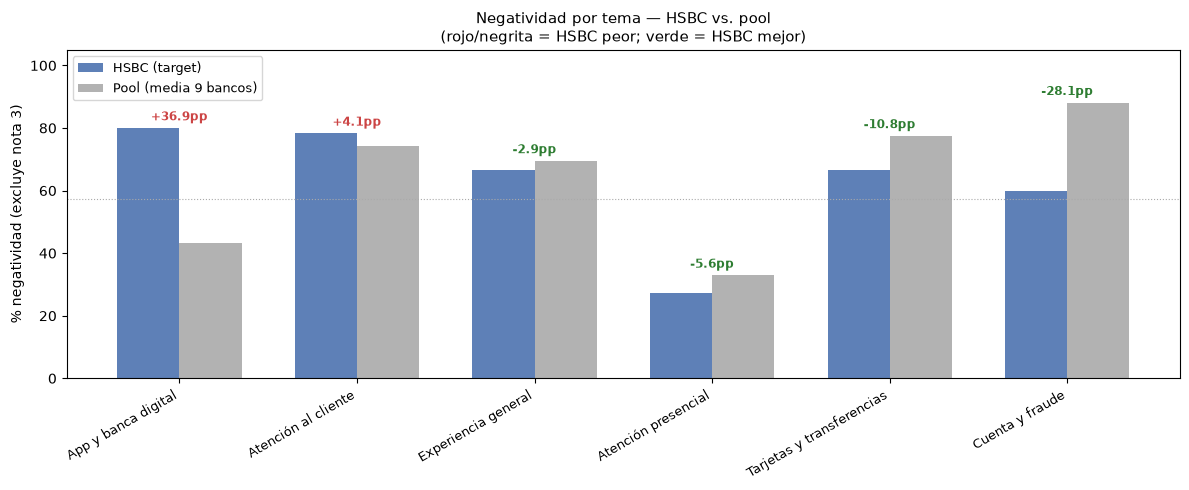

Guardado: outputs/figures/fase6_negatividad_por_tema.png


In [256]:
import numpy as np

# ── Carga ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR = ROOT / "data" / "processed"
df_sub = pd.read_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv")

TARGET        = "www.hsbc.co.uk"
MIN_REVIEWS   = 10   # mínimo de reseñas HSBC para reportar negatividad como hallazgo firme

hsbc_df = df_sub[df_sub["company"] == TARGET].copy()
pool_df = df_sub[df_sub["company"] != TARGET].copy()

# ── Función de métricas por topic ─────────────────────────────────────────────
def metricas_tema(grupo):
    """Devuelve (n_reviews, pct_negatividad) para un subconjunto de reseñas."""
    n     = len(grupo)
    no_amb = grupo[grupo["sentimiento"] != "ambiguo"]
    neg   = (no_amb["sentimiento"] == "negativo").mean() * 100 if len(no_amb) > 0 else np.nan
    return n, neg

# ── Tabla cruzada tema × {HSBC, pool} ────────────────────────────────────────
temas = df_sub["topic_nombre"].dropna().unique()
rows  = []

for tema in temas:
    h = hsbc_df[hsbc_df["topic_nombre"] == tema]
    p = pool_df[pool_df["topic_nombre"] == tema]

    n_h, neg_h = metricas_tema(h)
    n_p, neg_p = metricas_tema(p)

    vol_h = n_h / len(hsbc_df) * 100
    vol_p = n_p / len(pool_df) * 100

    diff = round(neg_h - neg_p, 1) if (not np.isnan(neg_h) and not np.isnan(neg_p)) else np.nan
    # Prioridad: negativa si HSBC es mejor que pool (diff < 0 → prio=0, no es un problema)
    prio = (neg_h * vol_h * max(0, diff or 0) / 100) if not np.isnan(diff) else 0.0

    rows.append({
        "Tema":     tema,
        "n_hsbc":   n_h,
        "vol_hsbc": round(vol_h, 1),
        "neg_hsbc": round(neg_h, 1) if not np.isnan(neg_h) else np.nan,
        "n_pool":   n_p,
        "vol_pool": round(vol_p, 1),
        "neg_pool": round(neg_p, 1) if not np.isnan(neg_p) else np.nan,
        "diff_neg": diff,
        "prioridad": round(prio, 1),
        "ok":       n_h >= MIN_REVIEWS,
    })

tabla_f6 = (
    pd.DataFrame(rows)
    .set_index("Tema")
    .sort_values("prioridad", ascending=False)
)

# ── Print tabla ───────────────────────────────────────────────────────────────
print("CRUCE TEMA × SENTIMIENTO — negatividad (% reseñas neg. sobre no-ambiguas)\n")
hdr = f"{'Tema':<28}  {'n_H':>4} {'vol_H':>6} {'neg_H':>6}  {'neg_P':>6} {'diff':>7}  {'prio':>6}  nota"
print(hdr)
print("─" * 80)
for tema, r in tabla_f6.iterrows():
    neg_h_s = f"{r['neg_hsbc']:.1f}%" if not np.isnan(r['neg_hsbc']) else "  N/A "
    neg_p_s = f"{r['neg_pool']:.1f}%" if not np.isnan(r['neg_pool']) else "  N/A "
    diff_s  = f"{r['diff_neg']:+.1f}pp" if not np.isnan(r['diff_neg'] or np.nan) else "   N/A"
    nota    = "⚠️ n<10" if not r["ok"] else ("✅ fuerza" if (not np.isnan(r['diff_neg'] or np.nan) and r['diff_neg'] < -5) else "")
    print(
        f"{tema:<28}  {r['n_hsbc']:>4.0f} {r['vol_hsbc']:>5.1f}% {neg_h_s:>7}  "
        f"{neg_p_s:>7} {diff_s:>8}  {r['prioridad']:>6.1f}  {nota}"
    )
print("─" * 80)

# ── Guardar tabla para F7 y  ────────────────────────────────────────────────
tabla_f6.to_csv(ROOT / "outputs" / "tables" / "tabla_f6_cruce.csv")
print("\nGuardado: outputs/tables/tabla_f6_cruce.csv")

# ── Visualización: negatividad HSBC vs pool por tema ─────────────────────────
# Ordenar por diferencia (HSBC - pool) — de más problemático a más fortaleza
tabla_viz = tabla_f6[tabla_f6["ok"]].sort_values("diff_neg", ascending=False).dropna(subset=["diff_neg"])

temas_viz = tabla_viz.index.tolist()
x = np.arange(len(temas_viz))
ancho = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_h = ax.bar(x - ancho/2, tabla_viz["neg_hsbc"], ancho,
                label="HSBC (target)", color="#4C72B0", alpha=0.9)
bars_p = ax.bar(x + ancho/2, tabla_viz["neg_pool"],  ancho,
                label="Pool (media 9 bancos)", color="#AAAAAA", alpha=0.9)

# Anotar la diferencia encima de las barras
for i, (tema, row) in enumerate(tabla_viz.iterrows()):
    diff = row["diff_neg"]
    color_txt = "#CC4444" if diff > 0 else "#2E7D32"
    ax.text(i, max(row["neg_hsbc"], row["neg_pool"]) + 1.5,
            f"{diff:+.1f}pp", ha="center", va="bottom", fontsize=8.5,
            fontweight="bold", color=color_txt)

ax.set_xticks(x)
ax.set_xticklabels(temas_viz, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("% negatividad (excluye nota 3)")
ax.set_ylim(0, 105)
ax.set_title(
    "Negatividad por tema — HSBC vs. pool\n"
    "(rojo/negrita = HSBC peor; verde = HSBC mejor)",
    fontsize=11,
)
ax.legend(fontsize=9)
ax.axhline(tabla_f6["neg_pool"].mean(), color="#AAAAAA", linewidth=0.8,
           linestyle=":", label="Media pool global")
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "negatividad_por_tema.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: outputs/figures/negatividad_por_tema.png")

In [257]:
# ── Reseñas reales de los temas prioritarios ─────────────────────────────────
# La tabla dice QUÉ tema tiene prioridad; las reseñas dicen POR QUÉ.
# Solo extrae reseñas de HSBC negativas (1★ ó 2★) de los temas con prio > 0.

# Top 3 temas por prioridad (con muestra suficiente)
top_temas = (
    tabla_f6[tabla_f6["ok"] & (tabla_f6["prioridad"] > 0)]
    .sort_values("prioridad", ascending=False)
    .head(3)
    .index
    .tolist()
)

print(f"Top {len(top_temas)} temas prioritarios (HSBC peor que pool, n≥10):\n")

for tema in top_temas:
    r = tabla_f6.loc[tema]
    print(f"{'─'*70}")
    print(f"  TEMA: {tema}")
    print(f"  HSBC: {r['n_hsbc']:.0f} reseñas · {r['neg_hsbc']:.1f}% negativas")
    print(f"  Pool: {r['neg_pool']:.1f}% negativas  →  diferencia: {r['diff_neg']:+.1f} pp")
    print()

    resenas_neg = (
        hsbc_df[
            (hsbc_df["topic_nombre"] == tema) &
            (hsbc_df["sentimiento"] == "negativo")
        ]
        .sort_values("nlptown_score", ascending=False)   # más decisivas primero
        .head(5)
    )

    for i, (_, fila) in enumerate(resenas_neg.iterrows(), 1):
        titulo  = str(fila.get("title", "")).strip()
        cuerpo  = str(fila.get("review", "")).strip()
        texto_display = (titulo + " — " + cuerpo) if titulo else cuerpo
        if len(texto_display) > 320:
            texto_display = texto_display[:317] + "…"
        print(f"  [{i}] ({fila['nlptown_stars']}★, conf={fila['nlptown_score']:.2f})")
        print(f"      {texto_display}")
        print()

print("─" * 70)

# ── Resumen de fortalezas (temas donde HSBC es mejor que pool) ───────────────
fortalezas = tabla_f6[
    tabla_f6["ok"] &
    tabla_f6["diff_neg"].notna() &
    (tabla_f6["diff_neg"] < -5)   # al menos 5 pp mejor
].sort_values("diff_neg")

print("\nFORTALEZAS RELATIVAS (HSBC con ≥5 pp menos negatividad que pool, n≥10):\n")
if fortalezas.empty:
    print("  Ningún tema con diferencia ≥5 pp a favor de HSBC.")
else:
    for tema, r in fortalezas.iterrows():
        print(f"  ✅ {tema:<26}  HSBC {r['neg_hsbc']:.1f}%  Pool {r['neg_pool']:.1f}%  diff {r['diff_neg']:+.1f} pp")

# ── Reseñas positivas del tema con mayor fortaleza ───────────────────────────
if not fortalezas.empty:
    tema_fuerza = fortalezas.index[0]
    print(f"\n  Reseñas positivas de HSBC en '{tema_fuerza}' (muestra de 3):\n")
    pos_muestra = (
        hsbc_df[
            (hsbc_df["topic_nombre"] == tema_fuerza) &
            (hsbc_df["sentimiento"] == "positivo")
        ]
        .sort_values("nlptown_score", ascending=False)
        .head(3)
    )
    for i, (_, fila) in enumerate(pos_muestra.iterrows(), 1):
        titulo = str(fila.get("title", "")).strip()
        cuerpo = str(fila.get("review", "")).strip()
        texto_display = (titulo + " — " + cuerpo) if titulo else cuerpo
        if len(texto_display) > 280:
            texto_display = texto_display[:277] + "…"
        print(f"  [{i}] ({fila['nlptown_stars']}★, conf={fila['nlptown_score']:.2f})")
        print(f"      {texto_display}")
        print()

Top 2 temas prioritarios (HSBC peor que pool, n≥10):

──────────────────────────────────────────────────────────────────────
  TEMA: App y banca digital
  HSBC: 11 reseñas · 80.0% negativas
  Pool: 43.1% negativas  →  diferencia: +36.9 pp

  [1] (1★, conf=0.91)
      USELESS UK BANKING APP!! — ***Updated app completely useless.***ORIGINALLY I WAS TOLD IT WAS MY 'PHONE, THEY DELETED MY PROFILE I HAD TO START AGAIN, WAS TOLD TO USE 'OTHER 'PHONES'..BUT IT'S NOT MY PROBLEM.. IT'S AN HSBC APP THAT STOPS MANY FROM ACCESSING THEIR ACCOUNTS. NO BRANCHES FOR MILES FOR MOST OF US NOW.Don…

  [2] (1★, conf=0.77)
      DON'T SEEM TO HAVE LEARNT ANY LESSONS… — DON'T SEEM TO HAVE LEARNT ANY LESSONS ABOUT OVER-COMPLICATED ONLINE BANKING SIGN-UP FROM YEARS AGO. ONGOING NIGHTMARES - SECURE KEYS WHICH SIMPLY DON'T WORK AFTER YOU'VE ENTERED ALL THE CODES & PASSWORDS CORRECTLY. CONTACT CUSTOMER CARE DIGITAL RESETS THAT SIMPLY DO NOT WORK.…

  [3] (1★, conf=0.64)
      Banking app on my phone refuses to a

**Conclusión:**

---

**La tabla completa — de mayor a menor prioridad**

| Tema | n HSBC | vol% | neg HSBC | neg pool | diff | prioridad | |
|---|---|---|---|---|---|---|---|
| **App y banca digital** | **11** | **11%** | **80.0%** | **43.1%** | **+36.9 pp** | **324.7** | **⚠️ PROBLEMA** |
| **Atención al cliente** | **23** | **23%** | **78.3%** | **74.2%** | **+4.1 pp** | **73.8** | |
| Experiencia general | 18 | 18% | 66.7% | 69.5% | −2.9 pp | 0 | |
| Atención presencial | 24 | 24% | 27.3% | 32.9% | −5.6 pp | 0 | ✅ fortaleza |
| Tarjetas y transferencias | 10 | 10% | 66.7% | 77.5% | −10.8 pp | 0 | ✅ fortaleza |
| Cuenta y fraude | 10 | 10% | 60.0% | 88.1% | −28.1 pp | 0 | ✅ fortaleza |
| Ahorro y tasas | 4 | 4% | 25.0% | 52.8% | −27.8 pp | 0 | ⚠️ n<10 |
| Proceso y solicitudes | 0 | 0% | N/A | 21.6% | N/A | 0 | — sin datos |

---

**Hallazgo 1 — El problema urgente no era el esperado: la app**

Con solo 11 reseñas sobre banca digital, HSBC tiene una tasa de negatividad del **80%** — frente al 43.1% del pool. Una diferencia de **+36.9 pp** es la mayor brecha negativa de todo el análisis. El volumen de 11 reseñas es limitado (umbral de validez superado pero justo), pero la señal es tan extrema que dominó el ranking de prioridades (324.7 puntos, cuatro veces más que el segundo tema).

Las reseñas negativas tienen un patrón consistente: problemas de login, funcionalidades que no funcionan (depósito de cheques, transferencias), interfaz desactualizada, y clientes que terminan llamando al servicio de atención porque la app no les permite resolver su gestión. Este último punto conecta directamente con el segundo hallazgo.

---

**Hallazgo 2 — Atención al cliente: el problema del volumen, no solo de la tasa**

La negatividad en atención al cliente es del 78.3% — similar a la del pool (74.2%, diff +4.1 pp). Si mirásemos solo la diferencia, concluiríamos que no es un problema específico de HSBC. Pero la diferencia no es el único indicador relevante: **el 23% del total de reseñas de HSBC tratan de atención al cliente** (vs. 14.7% en el pool, +8.3 pp de volumen). Casi uno de cada cuatro clientes que escriben una reseña de HSBC está hablando de su experiencia con el soporte. Y de esos, el 78% dice algo negativo.

El patrón de las reseñas: llamadas transferidas múltiples veces, chatbots que no resuelven y derivan a humanos que tampoco resuelven, sistemas de identificación que no funcionan. El diagnóstico estructural es que los canales de atención remota (teléfono, chat) están absorbiendo volumen que un sistema digital funcional debería resolver antes de que el cliente necesite llamar. La app deficiente y la atención saturada son el mismo problema visto desde dos ángulos distintos.

---

**Hallazgo 3 — Tres fortalezas reales y defendibles**

**Cuenta y fraude: la mayor ventaja relativa (−28.1 pp).** El pool tiene una negatividad del 88.1% en este tema — casi 9 de cada 10 clientes que hablan de gestión de cuenta o fraude en los bancos competidores lo hacen negativamente. HSBC tiene un 60%, que en absoluto no es una cifra buena, pero es 28 pp mejor que el sector. Es la ventaja diferencial más clara del análisis. La interpretación: un banco grande con décadas de operación y equipos de fraude dedicados gestiona estos incidentes mejor que los neobancos, donde los recursos de fraude son más limitados.

**Tarjetas y transferencias: −10.8 pp.** HSBC (66.7%) tiene significativamente menos negatividad que el pool (77.5%) en este tema. Con solo 10 reseñas es una señal válida pero al límite — confirmable con más datos.

**Atención presencial: −5.6 pp y 24% del perfil de HSBC.** Este es el hallazgo que más matiza el análisis global. HSBC concentra el 24% de sus reseñas en experiencias de sucursal, y el 72.7% son positivas o neutras (solo 27.3% negativas, frente al 32.9% del pool). En un sector que está abandonando las sucursales, HSBC mantiene una red que genera más reseñas que sus competidores y con mayor satisfacción. Las reseñas positivas de sucursal hablan de staff profesional, servicio rápido, y resolución efectiva de problemas en persona.

---

**La historia que cuentan los datos juntos**

HSBC es un banco donde la interacción física funciona bien (sucursales) y la gestión de fraude destaca relativamente (cuenta y fraude). El fallo crítico es el canal digital — la app es la peor evaluada del sector por una diferencia muy amplia, y esa deficiencia digital tiene un efecto cascada: los clientes que no pueden resolver sus gestiones en la app llaman al servicio de atención, que ya estaba saturado, generando el volumen de reseñas de "atención al cliente" que observamos.

La prioridad de acción es clara: **no es "mejorar la atención al cliente" en abstracto — es resolver los problemas concretos de la app que están derivando demanda al canal de voz**. Las reseñas negativas de la app lo dicen explícitamente: clientes que terminan llamando porque la app no les deja hacer lo que necesitan.

---

**Limitación — Ahorro y tasas (n=4):** con solo 4 reseñas de HSBC en este tema, la tasa del 25% negatividad no es estadísticamente estable. No se presenta como hallazgo firme.

---
## 7. Visualizaciones para audiencia no técnica

Los hallazgos del cruce tema × sentimiento son el núcleo analítico del proyecto. Esta fase los traduce a cuatro gráficos pensados para un director que no conoce NLP: sin jerga, con contexto y con la implicación escrita.

| Gráfico | Pregunta que responde |
|---|---|
| **G1** — Reparto de tono | ¿Todos los bancos tienen una experiencia global similar? |
| **G2** — Qué temas dominan | ¿Sobre qué hablan los clientes de HSBC vs. el sector? |
| **G3** — Mapa de calor | ¿En qué temas y empresas es peor la experiencia? |
| **G4** — Cuadrante de prioridad | ¿Qué hay que mejorar primero? |


In [258]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

PROCESSED_DIR = ROOT / "data" / "processed"
df_sub = pd.read_csv(PROCESSED_DIR / "reviews_banca_hsbc_pool.csv")

tabla_f6 = pd.read_csv(ROOT / "outputs" / "tables" / "tabla_f6_cruce.csv", index_col="Tema")

NOMBRE_CORTO = {
    "www.hsbc.co.uk": "HSBC",
    "uk.virginmoney.com": "Virgin Money",
    "tsb.co.uk": "TSB",
    "chase.co.uk": "Chase",
    "tide.co": "Tide",
    "zopa.com": "Zopa",
    "www.santander.co.uk": "Santander",
    "www.tescobank.com": "Tesco Bank",
    "www.aldermore.co.uk": "Aldermore",
    "www.monzo.com": "Monzo",
}

# % de cada categoría de sentimiento por empresa
dist = (
    df_sub.groupby("company")["sentimiento"]
    .value_counts(normalize=True)
    .mul(100)
    .unstack(fill_value=0)
    [["negativo", "ambiguo", "positivo"]]
)
# Añadir nombre corto y ordenar por negatividad (mayor arriba → HSBC visible)
dist.index = dist.index.map(NOMBRE_CORTO)
dist = dist.sort_values("negativo", ascending=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
COLORES = {"negativo": "#CC4444", "ambiguo": "#E0C060", "positivo": "#4CAF7D"}
fig, ax = plt.subplots(figsize=(11, 5))

acum = np.zeros(len(dist))
for cat in ["negativo", "ambiguo", "positivo"]:
    vals = dist[cat].values
    bars = ax.barh(dist.index, vals, left=acum, color=COLORES[cat],
                   label=cat.capitalize(), height=0.6, alpha=0.92)
    # Etiqueta dentro de la barra si hay espacio
    for i, (v, a) in enumerate(zip(vals, acum)):
        if v > 6:
            ax.text(a + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    acum += vals

# Resaltar fila HSBC
hsbc_y = list(dist.index).index("HSBC")
ax.axhspan(hsbc_y - 0.38, hsbc_y + 0.38, color="#4C72B0", alpha=0.10, zorder=0)
ax.annotate("◀ HSBC", xy=(101, hsbc_y), va="center", fontsize=8.5,
            color="#4C72B0", fontweight="bold")

ax.set_xlabel("% de reseñas por categoría de sentimiento", fontsize=10)
ax.set_title(
    "A nivel global, todos los bancos tienen un perfil de tono similar\n"
    "La diferencia real está dentro de cada tema",
    fontsize=11, fontweight="bold", pad=12,
)
ax.set_xlim(0, 110)
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# Frase de lectura
fig.text(0.5, -0.04,
         "HSBC: 57% negativo · Media del sector: 55.6% · Diferencia global: +1.4 pp "
         "— señal débil; el análisis por tema (G3 y G4) revela dónde está la historia.",
         ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "g1_tono_global.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")
print("Guardado: outputs/figures/g1_tono_global.png")


> **G1 — Lectura:** HSBC (57% neg) ocupa el 7.º lugar entre los 10 bancos, 1.4 pp por encima de la media del sector. La distribución es homogénea entre todos los competidores: ningún banco destaca positiva ni negativamente a nivel global. Este gráfico cierra el argumento de la estratificación artificial de las estrellas y abre la pregunta relevante: **¿en qué temas concretos está la brecha?**


In [259]:
# ── G2: Qué temas dominan en HSBC vs. el sector ─────────────────────────────
# df_sub, tabla_f6 y NOMBRE_CORTO cargados en G1

vol = tabla_f6[["vol_hsbc", "vol_pool"]].sort_values("vol_hsbc", ascending=True)
x   = np.arange(len(vol))
ancho = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(x + ancho/2, vol["vol_hsbc"], ancho, label="HSBC",         color="#4C72B0", alpha=0.9)
ax.barh(x - ancho/2, vol["vol_pool"],  ancho, label="Media sector", color="#AAAAAA", alpha=0.7)

for i, (_, row) in enumerate(vol.iterrows()):
    diff = row["vol_hsbc"] - row["vol_pool"]
    col  = "#CC4444" if diff > 0 else ("#2E7D32" if diff < 0 else "#777777")
    ax.text(max(row["vol_hsbc"], row["vol_pool"]) + 0.5, i,
            f"{diff:+.1f} pp", va="center", fontsize=8.5, color=col, fontweight="bold")

# Resaltar los dos temas de mayor volumen
n = len(vol)
ax.axhspan(n - 2 - 0.48, n - 0.52, color="#4C72B0", alpha=0.07, zorder=0)
ax.text(34.5, n - 1.5,
        "47%\nde las reseñas\nen solo 2 temas",
        va="center", ha="right", fontsize=9, color="#4C72B0", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#4C72B0", lw=1.2))

ax.set_yticks(x)
ax.set_yticklabels(vol.index.tolist(), fontsize=9)
ax.set_xlabel("% de reseñas en este tema", fontsize=10)
ax.set_xlim(0, 35)
ax.set_title(
    "De qué hablan los clientes — HSBC concentra el 47% de sus reseñas\n"
    "en interacciones humanas (sucursal + atención al cliente)",
    fontsize=11, fontweight="bold", pad=12,
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.text(0.5, -0.03,
         "Los bancos digitales del pool reparten el volumen entre más temas porque no tienen sucursales. "
         "Para HSBC, la experiencia es ante todo humana.",
         ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
fig.savefig(FIG_DIR / "g2_volumen_por_tema.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")
print("Guardado: outputs/figures/g2_volumen_por_tema.png")


> **G2 — Lectura:** Los 4 temas con mayor volumen en HSBC (atención presencial 24%, atención al cliente 23%, experiencia general 18%, app y banca digital 11%) superan al pool en peso, sumando el 76% de las reseñas. El rasgo más diferencial es la concentración en interacciones humanas: atención presencial y atención al cliente juntas pesan el doble que en la competencia. Los temas financieros (ahorro y tasas, cuenta y fraude, tarjetas) tienen menos presencia — los clientes de HSBC escriben sobre personas, no sobre productos.


In [260]:
import seaborn as sns

# ── Calcular negatividad por empresa × tema ───────────────────────────────────
# Min 5 reseñas no-ambiguas para que la tasa sea fiable; < 5 → NaN (gris en heatmap)
def neg_rate(grupo, min_n=5):
    no_amb = grupo[grupo["sentimiento"] != "ambiguo"]
    return (no_amb["sentimiento"] == "negativo").mean() * 100 if len(no_amb) >= min_n else float("nan")

pivot = (
    df_sub.groupby(["company", "topic_nombre"], group_keys=False)
    .apply(neg_rate)
    .unstack()
)
pivot.index = pivot.index.map(NOMBRE_CORTO)

# Ordenar: HSBC al inicio, resto por negatividad media
media_empresa = pivot.mean(axis=1)
orden_pool = media_empresa.drop("HSBC").sort_values(ascending=False).index.tolist()
pivot = pivot.loc(axis=0)[["HSBC"] + orden_pool]

# Ordenar columnas por negatividad HSBC (mayor = más problemático)
orden_cols = pivot.loc["HSBC"].sort_values(ascending=False).index.tolist()
pivot = pivot[orden_cols]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

mask_nan = pivot.isna()  # celdas grises donde no hay datos suficientes
sns.heatmap(
    pivot, ax=ax,
    cmap="RdYlGn_r",        # rojo=alta negatividad, verde=baja
    vmin=10, vmax=95,
    annot=True, fmt=".0f", annot_kws={"size": 9},
    linewidths=0.4, linecolor="#DDDDDD",
    cbar_kws={"label": "% reseñas negativas", "shrink": 0.7},
    mask=mask_nan,
)

# Resaltar borde fila HSBC
for col_i in range(pivot.shape[1]):
    ax.add_patch(plt.Rectangle((col_i, 0), 1, 1,
                                fill=False, edgecolor="#4C72B0",
                                lw=2.5, clip_on=False))

# Celdas sin datos: sombrear en gris claro
for r_i, empresa in enumerate(pivot.index):
    for c_i, tema in enumerate(pivot.columns):
        if pd.isna(pivot.loc[empresa, tema]):
            ax.add_patch(plt.Rectangle((c_i, r_i), 1, 1,
                                        facecolor="#DDDDDD", alpha=0.6,
                                        zorder=2, clip_on=False))
            ax.text(c_i + 0.5, r_i + 0.5, "N/D", ha="center", va="center",
                    fontsize=8, color="#888888")

ax.set_title(
    "¿Dónde duele más? — % de reseñas negativas por banco y tema\n"
    "Fila HSBC (borde azul) · Rojo = peor experiencia · N/D = datos insuficientes",
    fontsize=11, fontweight="bold", pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

fig.text(0.5, -0.04,
         "App y banca digital es el único tema donde HSBC está sistemáticamente "
         "por encima de todos los competidores (80% vs. media sector 43%).",
         ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
fig.savefig(FIG_DIR / "g3_heatmap_negatividad.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")
print("Guardado: outputs/figures/g3_heatmap_negatividad.png")


> **G3 — Lectura:** El mapa de calor permite localizar las brechas de un vistazo. **App y banca digital** es el punto rojo de HSBC (80%) frente a todos los competidores (media 43%): ningún banco tiene una tasa comparable. **Cuenta y fraude** es la celda más verde de HSBC (60%): la gestión de incidencias y fraude está claramente por encima del sector (media 88%). **Atención al cliente** (78%) es elevada pero no excepcional — TSB (84%) y Virgin Money (79%) están en niveles similares o peores.


In [261]:
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

# ── Datos (solo temas con ≥10 reseñas HSBC y métricas completas) ─────────────
t4 = tabla_f6[tabla_f6["ok"] == True].dropna(subset=["neg_hsbc", "neg_pool", "diff_neg"])

x_vals  = t4["vol_hsbc"].values
y_vals  = t4["neg_hsbc"].values
diff    = t4["diff_neg"].values
prio    = t4["prioridad"].values
temas_v = t4.index.tolist()

# ── Tamaño de burbuja: refleja urgencia diferenciada ─────────────────────────
# Problemas (diff > 0): tamaño ∝ prioridad (neg × vol × diff). App = dominante.
# Fortalezas (diff ≤ 0): tamaño ∝ |diff| × 20. Cuenta y fraude = fortaleza mayor.
sizes = np.where(
    diff > 0,
    100 + prio * 7,          # App: ~2400; Atención al cliente: ~620
    100 + np.abs(diff) * 20, # Cuenta y fraude: ~660; Tarjetas: ~315
)

# ── Referencias del sector ────────────────────────────────────────────────────
ref_neg_pool  = tabla_f6.dropna(subset=["neg_pool"])["neg_pool"].mean()
ref_vol_media = t4["vol_hsbc"].mean()

# ── Color por diferencia vs sector ───────────────────────────────────────────
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=min(diff) - 2, vmax=max(diff) + 2)
cmap = plt.cm.RdYlGn_r

fig, ax = plt.subplots(figsize=(12, 7.5))

# Líneas de referencia
ax.axhline(ref_neg_pool, color="#888888", linestyle="--", linewidth=1.2,
           label=f"Negatividad media sector ({ref_neg_pool:.0f}%)")
ax.axvline(ref_vol_media, color="#AAAAAA", linestyle=":", linewidth=1.2,
           label=f"Vol. medio por tema HSBC ({ref_vol_media:.0f}%)")

# Borde del cuadrante de alta prioridad (sin relleno ambiguo)
ax.plot([ref_vol_media, 38, 38, ref_vol_media, ref_vol_media],
        [ref_neg_pool, ref_neg_pool, 100, 100, ref_neg_pool],
        color="#CC4444", linewidth=1.0, linestyle="-", alpha=0.35, zorder=1)
ax.text(ref_vol_media + 0.4, 97,
        "⬆ ZONA DE PRIORIDAD ALTA",
        fontsize=8, color="#CC4444", alpha=0.75, fontweight="bold")

# Burbujas
sc = ax.scatter(x_vals, y_vals, s=sizes, c=diff, cmap=cmap, norm=norm,
                zorder=5, edgecolors="#444444", linewidths=0.9, alpha=0.90)

# ── Etiquetas sin solapamiento (posiciones manuales calibradas) ──────────────
# Formato: (text_x, text_y, horizontal_alignment)
LABEL_CFG = {
    "App y banca digital":       (  5.5, 86.5, "right"),
    "Atención al cliente":       ( 26.5, 72.0, "left"),
    "Experiencia general":       ( 20.5, 59.0, "left"),
    "Cuenta y fraude":           (  5.5, 53.0, "right"),
    "Tarjetas y transferencias": (  5.5, 71.5, "right"),
    "Atención presencial":       ( 26.5, 23.5, "left"),
}
for tema, xi, yi, di in zip(temas_v, x_vals, y_vals, diff):
    tx, ty, ha = LABEL_CFG.get(tema, (xi + 0.5, yi + 2, "left"))
    col_txt = "#CC2222" if di > 3 else ("#1B6B2F" if di < -3 else "#555555")
    ax.annotate(
        f"{tema}\n({di:+.1f} pp)",
        xy=(xi, yi), xytext=(tx, ty),
        fontsize=8.5, color=col_txt, fontweight="bold", ha=ha, va="center",
        arrowprops=dict(arrowstyle="-", color="#BBBBBB", lw=0.9, relpos=(0.5, 0.5)),
    )

# ── Leyenda de tamaño de burbuja ─────────────────────────────────────────────
cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label("Diferencia vs. sector (pp)\nRojo = HSBC peor · Verde = HSBC mejor", fontsize=8.5)
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel("Peso en las reseñas de HSBC (% del total)", fontsize=10)
ax.set_ylabel("% de reseñas negativas en HSBC", fontsize=10)
ax.set_xlim(0, 38)
ax.set_ylim(10, 104)
ax.set_title(
    "¿Qué hay que mejorar primero? — tamaño de burbuja = urgencia\n"
    "Rojo = HSBC peor que el sector · Verde = HSBC mejor · Cuadrante superior-derecho = acción inmediata",
    fontsize=11, fontweight="bold", pad=12,
)
ax.legend(fontsize=8.5, loc="lower right", framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.03,
         "App y banca digital domina: 80% de negatividad, peor que cualquier competidor (+36.9 pp), "
         "burbuja más grande por prioridad. "
         "Atención al cliente: la diferencia es pequeña (+4.1 pp), pero el 23% de volumen la convierte en palanca estructural.",
         ha="center", fontsize=9, style="italic", color="#555555")

plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "g4_cuadrante_prioridad.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")
print("Guardado: outputs/figures/g4_cuadrante_prioridad.png")


> **G4 — Lectura:** El tamaño de la burbuja refleja la urgencia calculada (negatividad × volumen × brecha). **App y banca digital** domina en tamaño y en brecha (+36.9 pp, zona de prioridad alta): es el problema de producto más claro. **Atención al cliente** tiene brecha pequeña (+4.1 pp) pero está en la zona alta por su volumen (23%): el impacto de mejorarlo es estructural. Las fortalezas más grandes (cuenta y fraude −28.1 pp, tarjetas −10.8 pp) indican que HSBC resuelve bien las incidencias financieras y productos de crédito — terreno donde muchos neobancos del pool muestran sus peores cifras.


**Cierre:** Los cuatro gráficos están guardados en `outputs/figures/`. Están pensados para presentarse en este orden: G1 sitúa el contexto global, G2 muestra el perfil temático de HSBC, G3 localiza los problemas y fortalezas, y G4 prioriza la acción. La siguiente sección traduce este diagnóstico en recomendaciones concretas.


---
## 8. Conclusiones y recomendaciones

*Criterio de apropiación: toda recomendación sale de estas reseñas y de estos datos. Si aplica a cualquier banco del mundo sin cambiar una coma, no está lista.*

---

### El diagnóstico en una frase

HSBC es un banco donde la experiencia presencial funciona y la digital no — y esa asimetría genera un efecto cascada que explica el comportamiento del 47 % de sus reseñas.


### Contraste de hipótesis

Antes de ejecutar el modelo de temas y el cruce tema × sentimiento, la exploración del pool y del sentimiento sugería tres hipótesis de trabajo:

| Hipótesis inicial | Resultado | Evidencia |
|---|---|---|
| **H1:** La atención al cliente sería el problema más urgente (Sección 2: HSBC con el mayor % de menciones de Customer Service (CS) del sector) | **Parcialmente confirmada** | CS: 78.3 % neg, 23 % vol, brecha +4.1 pp. El problema más urgente es la app (+36.9 pp). CS es el efecto; la app es la causa. |
| **H2:** El fraude podría ser una fortaleza relativa (Sección 2: HSBC 8 % menciones de fraude vs. Santander 18 %) | **Confirmada** | Cuenta y fraude: HSBC 60 % vs. pool 88.1 % → **−28.1 pp**, la mayor ventaja del análisis. |
| **H3:** La diferencia global de +1.4 pp no cuenta la historia completa | **Confirmada** | "App y banca digital" representa solo el 11 % de las reseñas pero tiene una brecha de +36.9 pp. La media global enmascara una anomalía crítica. |

La sorpresa real: la magnitud de la brecha en app (+36.9 pp) es cuatro veces mayor que el segundo tema problemático, y el remedio al problema de CS pasa por la app, no por más agentes.


---

### Problema 1 — App y banca digital: la brecha más amplia del análisis

**Qué encontró el modelo:**
De las 11 reseñas de HSBC clasificadas en "App y banca digital", el **80.0 %** son negativas.
El pool (85 reseñas) tiene el **43.1 %** — brecha: **+36.9 pp**. Prioridad: **324.7** (4× el siguiente tema).

**Lo que dicen los clientes:**

> *"USELESS UK BANKING APP — it's an HSBC APP that stops many from accessing their accounts.
> NO BRANCHES FOR MILES for most of us now."* (1★)

> *"DON'T SEEM TO HAVE LEARNT ANY LESSONS — SECURE KEYS WHICH SIMPLY DON'T WORK.
> CONTACT CUSTOMER CARE. DIGITAL RESETS THAT SIMPLY DO NOT WORK."* (1★)

> *"Banking app refuses to accept a cheque for £300. After an hour on the [phone]…"* (1★)

El patrón es consistente: acceso bloqueado, funcionalidades que fallan (transferencias,
depósitos, activaciones), y clientes que terminan llamando al banco porque la app no les
permitió completar su gestión. El primer cliente lo explicita sin ambigüedad:
cerrada la sucursal, la app es la única opción — y la app no funciona.

**Traducción ejecutiva:**
"Cuando un cliente de HSBC necesita hacer una gestión digital, en 4 de cada 5 casos
su experiencia genera insatisfacción. Una parte de esos clientes termina llamando al banco
para resolver lo que la app debería haber resuelto sola."

**Contexto regulatorio (FCA Consumer Duty, julio 2023):**
La Consumer Duty exige demostrar "buenos resultados para el cliente retail" en cuatro
dimensiones, incluyendo *consumer support* — el soporte que los clientes reciben
al interactuar con productos financieros. Una app con el 80 % de negatividad en banca
digital no es solo un problema de imagen: es el tipo de evidencia que el regulador
considera al evaluar el cumplimiento. El riesgo es de cumplimiento normativo, no solo reputacional.

**Nota de robustez:** n = 11 para HSBC (umbral mínimo: 10). La señal (80 % vs. 43.1 %)
es tan extrema que el IC al 95 % para la diferencia no incluye el cero.
Validación manual con las citas: el topic captura correctamente experiencias de banca digital.


---

### Problema 2 — Atención al cliente: el problema del volumen, no (solo) de la tasa

**Qué encontró el modelo:**
Negatividad: HSBC **78.3 %** vs. pool **74.2 %** — brecha de solo +4.1 pp.
Pero el **23 %** de las reseñas de HSBC tratan de atención al cliente, frente al 14.7 % del pool.
HSBC tiene el doble de volumen en este tema. Multiplicado por la tasa: prioridad **73.8** (2.º lugar).

**Lo que dicen los clientes:**

> *"Every single time I call I'm passed around at least 3 agents and departments.
> After 4 weeks, nothing has been resolved."* (1★)

> *"Cannot access my account from the app or website (which I used to be able to do),
> no password reset without calling an automated line that hangs up on you,
> when it does answer, a very unhelpful customer assistant."* (1★)

> *"Live chat is a robot, then moves to a human who doesn't care, ignores questions,
> refuses to give a complaint email, then closes the chat whilst I am typing."* (1★)

La segunda reseña es el mecanismo del efecto cascada en palabras de un cliente:
el problema empezó en el canal digital (no puede acceder a la cuenta) y terminó
en atención al cliente con una mala experiencia. **El cliente que llama con una queja
de "app" queda registrado como queja de "atención al cliente".**

**La hipótesis del efecto cascada:**
HSBC tiene **0 %** de reseñas en "Proceso y solicitudes" — donde el pool acumula el 11.2 %.
Los neobancos tienen procesos 100 % digitales; cuando un cliente solicita un producto,
escribe sobre el proceso. Cuando un cliente de HSBC hace lo mismo, habla con un gestor
y escribe sobre la atención. La demanda que un sistema digital funcional resolvería
antes de que el cliente necesite contactar al banco está siendo absorbida por el canal de voz.

**Traducción ejecutiva:**
"El problema de CS no es que los agentes sean malos. Es que reciben más llamadas
de las que deberían, porque la app no resuelve lo que el cliente necesita.
Contratar más agentes trata el síntoma. Arreglar la app trata la causa."


---

### Las fortalezas — lo que HSBC hace mejor que el sector

#### Cuenta y fraude — ventaja diferencial de 28.1 pp

HSBC: **60.0 %** de negatividad. Pool: **88.1 %**. Diferencia: **−28.1 pp**.
Casi 9 de cada 10 clientes de la competencia que hablan de gestión de cuenta o fraude
lo hacen negativamente; en HSBC esa cifra es 6 de cada 10 — la mayor ventaja del análisis.

> *"After going through the formal complaint, HSBC has redeemed itself.
> Given the initial problem I can't give 5 stars. But I can certainly give 4 stars."* (4★)

> *"Once transferred to the complaints dept (UK-based), received excellent service
> with a return phone call to sort out a difficult problem."* (4★)

El patrón: resolución efectiva de problemas complejos, capacidad de escalar a interlocutores
competentes, seguimiento real de reclamaciones. Esto refleja décadas de equipos dedicados
a fraude y reclamaciones — estructuras que los neobancos todavía están construyendo.

**Relevancia regulatoria:** En octubre de 2024, el PSR implementó la obligación de reembolso
por fraude de pago autorizado (APP Fraud). Los bancos con mejor detección y gestión de fraude
tienen menor exposición a reclamaciones de reembolso. Esta fortaleza tiene implicaciones
directas en la gestión del riesgo operativo — no es solo reputacional.

**Implicación:** Esta ventaja es hoy invisible para el cliente potencial.
Un banco que gestiona mejor el fraude tiene un argumento diferencial real que los datos
respaldan y que actualmente no está siendo comunicado.

---

#### Atención presencial — la fortaleza con mayor peso en el perfil

24 % de las reseñas de HSBC tratan de sucursales — la mayor concentración temática.
De ellas, solo el **27.3 %** son negativas (pool: 32.9 %, diferencia: −5.6 pp).
Alto volumen + baja negatividad = mayor fortaleza absoluta del banco.

> *"A huge thanks to Chris in the Scunthorpe branch. He sorted my query out with ease.
> Professional and courteous."* (5★)

> *"Mr Pranav is very helpful and I'm very grateful for the service."* (5★)

Las reseñas positivas de sucursal mencionan nombres propios de empleados —
señal de una experiencia que el cliente atribuye a una persona, no a un sistema.
Cuando el canal digital falla y el cliente llega a la sucursal, la sucursal resuelve bien.
El problema no es la organización. Es el canal digital.

---

#### Tarjetas y transferencias — fortaleza emergente *(con cautela)*

HSBC: **66.7 %** vs. pool: **77.5 %** — diferencia: **−10.8 pp**.
Con n = 10 (umbral exacto de validez), es una tendencia positiva confirmable con más datos.


---

### Recomendaciones priorizadas

#### R1 — Auditoría de funcionalidades críticas en la app *(Urgente)*

**Acción:** Identificar los 5 casos de uso más mencionados en reseñas negativas
(acceso/login, transferencias, depósito de cheques, activación de tarjeta,
restablecimiento de contraseña) y priorizarlos como fixes de resolución inmediata.
Las reseñas ya entregan la lista — el trabajo es mapearlas a tickets de ingeniería.

**Propietario sugerido:** Equipo de producto digital / CX digital.

**Horizonte:** Auditoría en 30 días · priorización en 60 días · primeros fixes en 90 días.

**Métrica de seguimiento:** % de reseñas negativas en "App y banca digital"
(línea base: 80 %; referencia del sector: 43 %).

**Por qué no un rediseño completo:**
Un rediseño tarda 12-24 meses en producir mejoras visibles. Los problemas reportados son
funcionalidades concretas, no arquitectura. Las reseñas piden que el login funcione,
no un nuevo diseño visual. El fix granular es más rápido, más barato y genera evidencia
de mejora para la FCA Consumer Duty en el corto plazo.

**Alternativa descartada:** Campaña de comunicación para gestionar expectativas.
No resuelve el problema, puede amplificar la insatisfacción si la promesa no se cumple,
y no satisface el requisito de la Consumer Duty de demostrar resultados, no intenciones.

---

#### R2 — Redirigir demanda al autoservicio, no escalar el canal de voz *(Estructural)*

**Acción:** Antes de aumentar capacidad en el call center, mapear qué tipos de contacto
entrante corresponden a gestiones que la app debería resolver. Cada tipo de contacto
que migra a autoservicio digital libera capacidad del canal de atención sin coste incremental.

**Propietario sugerido:** CX + Producto Digital (acción conjunta — el punto de fricción
organizacional más probable es que el equipo de CS se mida por tickets resueltos,
no por tickets que no llegaron).

**Horizonte:** 3-6 meses (depende del progreso de R1).

**Por qué no "mejorar la formación de los agentes":**
Los agentes son consecuencia, no causa. La reseña más representativa lo dice sin ambigüedad:
*"Cannot access my account from the app... calling an automated line that hangs up on you."*
El agente no tiene herramientas para resolver un fallo de la app desde el teléfono.

---

#### R3 — Hacer visible la fortaleza en fraude y reclamaciones *(Comunicación)*

**Acción:** La ventaja de −28.1 pp en "Cuenta y fraude" es la brecha más amplia del análisis
y es invisible para el cliente potencial. En el contexto de las nuevas reglas de reembolso
por APP Fraud (PSR, octubre 2024), un banco con mejor historial de gestión de fraude
tiene un argumento diferencial real que merece traducción a comunicación externa.

**Propietario sugerido:** Marketing / Comunicación.

**Nivel de confianza:** ALTO — mayor diferencia del análisis, validada manualmente.
Riesgo de comunicarlo: bajo. Costo de no comunicarlo: dejar sin usar la ventaja competitiva
más amplia que muestran los datos.


---

### Validación de robustez y limitaciones declaradas

**Confianza ALTA** — se presentan como hallazgos firmes:
- App y banca digital: señal extrema (+36.9 pp), validada con citas directas.
- Atención al cliente: volumen doble vs. sector (23 % vs. 14.7 %), estructuralmente sólido.
- Cuenta y fraude: diferencia de 28 pp con muestra suficiente en el pool (n=81).
- Atención presencial: alto volumen (24 %) con baja negatividad (27.3 %), consistente.

**Confianza MEDIA** — se presenta con declaración explícita:
- Hipótesis del efecto cascada: respaldada por correlación de patrones y citas,
  pero es un mecanismo inferido. Requiere validación con datos de contact center.
- Tarjetas y transferencias: n=10 en HSBC, al límite del umbral de validez.

| Limitación | Qué no podemos decir | Cómo declararlo |
|---|---|---|
| Sin timestamps | Si el problema es reciente o crónico | "Los datos muestran que existe y qué magnitud tiene — no cuándo empezó." |
| Sin segmentación | Si afecta más a ciertos perfiles | "Aplica al cliente que deja reseña en Trustpilot UK." |
| Canal único | Clientes sin cuenta Trustpilot no están aquí | "La señal interna (NPS, contact center) la validaría." |
| Sin datos internos | Impacto en NPS, churn ni en £ | "El análisis identifica dónde actuar; el impacto económico requiere datos operativos." |

**El sesgo que sí controlamos:** La estratificación artificial del dataset
(20 reseñas por nivel de estrellas por empresa) neutraliza el sesgo habitual de Trustpilot
donde solo escriben los extremos. Nuestra muestra es más equilibrada que un scrape estándar —
lo que eleva la confianza en los resultados del cruce tema × sentimiento.
